Étape 1 — Imports

In [ ]:
!pip install xgboost
from xgboost import XGBRegressor

import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Étape 2 — Chargement des données

In [69]:
fichiers = glob.glob("eCO2mix_RTE_Annuel-Definitif_*.xls")
print(f"{len(fichiers)} fichiers trouvés")

dfs = []
for fichier in fichiers:
    df_temp = pd.read_csv(
        fichier,
        sep="\t",
        encoding="latin1",
        index_col=False,
        low_memory=False
    )
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
print(f"Dimensions : {df.shape}")

13 fichiers trouvés
Dimensions : (429517, 40)


Étape 3 — Nettoyage

In [70]:
# Aperçu des premières lignes
df.head(5)

,Périmètre,Nature,Date,Heures,Consommation,Prévision J-1,Prévision J,Fioul,Charbon,Gaz,...,Hydraulique - Fil de l?eau + éclusée,Hydraulique - Lacs,Hydraulique - STEP turbinage,Bioénergies - Déchets,Bioénergies - Biomasse,Bioénergies - Biogaz,Stockage batterie,Déstockage batterie,Eolien terrestre,Eolien offshore
0,France,Données définitives,2012-01-01,00:00,58315.0,58200.0,58200.0,492.0,25.0,3816.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN
1,France,Données définitives,2012-01-01,00:15,NaN,57700.0,57550.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,France,Données définitives,2012-01-01,00:30,58315.0,57200.0,56900.0,492.0,25.0,3816.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN
3,France,Données définitives,2012-01-01,00:45,NaN,56200.0,56000.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,France,Données définitives,2012-01-01,01:00,56231.0,55200.0,55100.0,492.0,25.0,3834.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN


In [71]:
# Infos générales
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 429517 entries, 0 to 429516
Data columns (total 40 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Périmètre                             429517 non-null  str    
 1   Nature                                429504 non-null  str    
 2   Date                                  429504 non-null  str    
 3   Heures                                429504 non-null  str    
 4   Consommation                          214752 non-null  float64
 5   Prévision J-1                         429504 non-null  float64
 6   Prévision J                           429504 non-null  float64
 7   Fioul                                 214752 non-null  float64
 8   Charbon                               214752 non-null  float64
 9   Gaz                                   214752 non-null  float64
 10  Nucléaire                             214752 non-null  float64
 11  Eolien     

In [72]:
# On garde seulement les 3 colonnes utiles
df = df[["Date", "Heures", "Consommation"]].copy()

# On supprime les lignes sans date ni heure
df = df.dropna(subset=["Date", "Heures"])

# On convertit la consommation en numérique
df["Consommation"] = pd.to_numeric(df["Consommation"], errors="coerce")

# On supprime les lignes sans consommation
avant = len(df)
df = df.dropna(subset=["Consommation"]).reset_index(drop=True)
apres = len(df)

print(f"Lignes supprimées : {avant - apres}")
print(f"Lignes restantes  : {apres}")

Lignes supprimées : 214752
Lignes restantes  : 214752


Étape 4 — Feature Engineering

On crée de nouvelles variables à partir de la date et de l'heure.
C'est ce que le modèle va utiliser pour apprendre.

- hour        : heure de la journée (0-23)
- day_of_week : jour de la semaine (0=lundi, 6=dimanche)
- month       : mois de l'année → effet saisonnier
- day         : jour du mois
- year        : année → tendance long terme
- is_weekend  : 1 si samedi/dimanche, 0 sinon

In [73]:
# Création du datetime combiné
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Heures"])

# Extraction des variables temporelles
df["hour"]        = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek
df["month"]       = df["datetime"].dt.month
df["day"]         = df["datetime"].dt.day
df["year"]        = df["datetime"].dt.year
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)

# Vérification
df[["datetime", "hour", "day_of_week", "month", "year", "is_weekend", "Consommation"]].head(10)

,datetime,hour,day_of_week,month,year,is_weekend,Consommation
0,2012-01-01 00:00:00,0,6,1,2012,1,58315.0
1,2012-01-01 00:30:00,0,6,1,2012,1,58315.0
2,2012-01-01 01:00:00,1,6,1,2012,1,56231.0
3,2012-01-01 01:30:00,1,6,1,2012,1,56075.0
4,2012-01-01 02:00:00,2,6,1,2012,1,55532.0
5,2012-01-01 02:30:00,2,6,1,2012,1,54911.0
6,2012-01-01 03:00:00,3,6,1,2012,1,52496.0
7,2012-01-01 03:30:00,3,6,1,2012,1,50664.0
8,2012-01-01 04:00:00,4,6,1,2012,1,49161.0
9,2012-01-01 04:30:00,4,6,1,2012,1,47596.0


Étape 5 — Visualisation exploratoire


Avant de modéliser, on visualise la consommation moyenne 
en fonction de chaque variable temporelle pour vérifier 
que nos features sont bien liées à la cible.

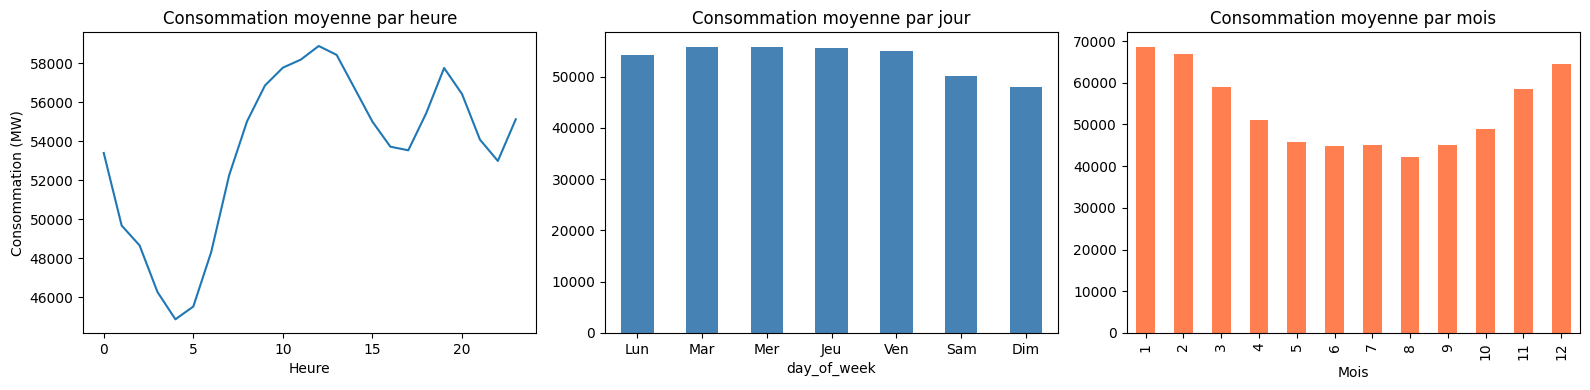

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Par heure
df.groupby("hour")["Consommation"].mean().plot(ax=axes[0])
axes[0].set_title("Consommation moyenne par heure")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("Consommation (MW)")

# Par jour de la semaine
df.groupby("day_of_week")["Consommation"].mean().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Consommation moyenne par jour")
axes[1].set_xticklabels(["Lun","Mar","Mer","Jeu","Ven","Sam","Dim"], rotation=0)

# Par mois
df.groupby("month")["Consommation"].mean().plot(kind="bar", ax=axes[2], color="coral")
axes[2].set_title("Consommation moyenne par mois")
axes[2].set_xlabel("Mois")

plt.tight_layout()
plt.show()

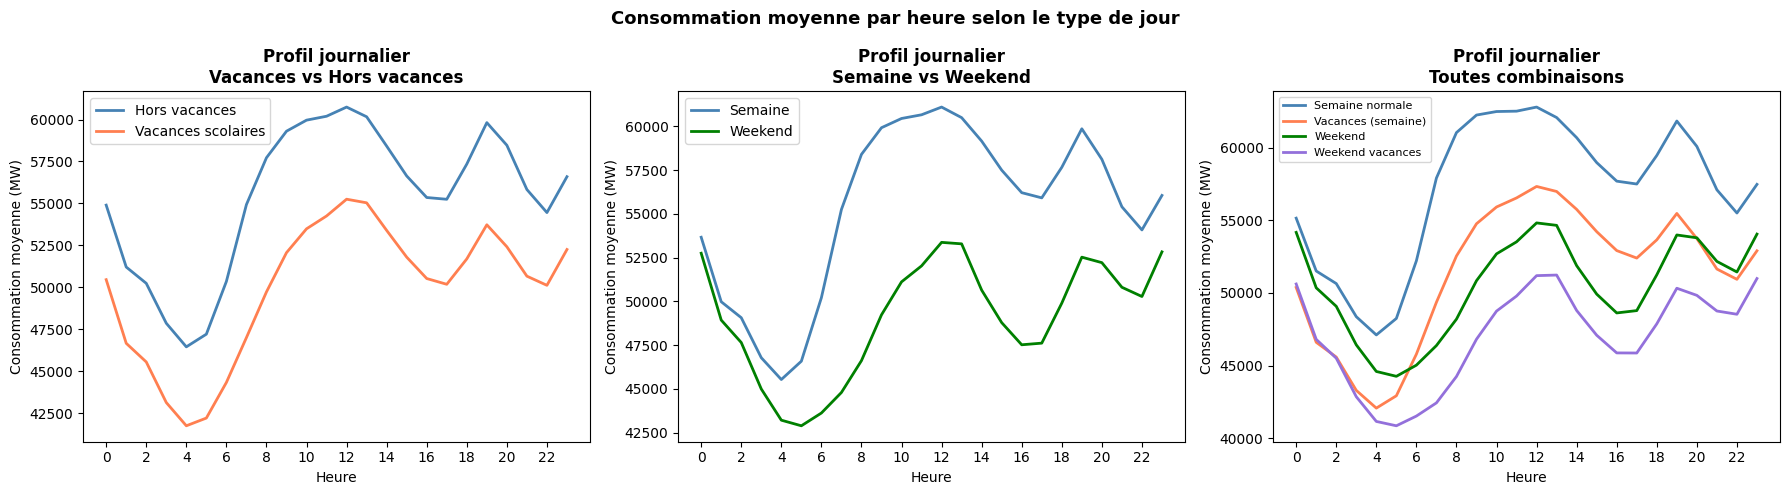

In [120]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Graphique 1 : jours de vacances scolaires ---
conso_vac_heure = df_E.groupby(["is_vacances", "hour"])["Consommation"].mean().unstack(0)
conso_vac_heure.columns = ["Hors vacances", "Vacances scolaires"]

conso_vac_heure.plot(ax=axes[0], color=["steelblue", "coral"], linewidth=2)
axes[0].set_title("Profil journalier\nVacances vs Hors vacances", fontweight="bold")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("Consommation moyenne (MW)")
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()

# --- Graphique 2 : jours de weekend ---
conso_we_heure = df_E.groupby(["is_weekend", "hour"])["Consommation"].mean().unstack(0)
conso_we_heure.columns = ["Semaine", "Weekend"]

conso_we_heure.plot(ax=axes[1], color=["steelblue", "green"], linewidth=2)
axes[1].set_title("Profil journalier\nSemaine vs Weekend", fontweight="bold")
axes[1].set_xlabel("Heure")
axes[1].set_ylabel("Consommation moyenne (MW)")
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

# --- Graphique 3 : les 3 combinaisons ensemble ---
# Jours normaux = semaine + pas vacances
# Vacances semaine = vacances + pas weekend
# Weekend = weekend + pas vacances
mask_normal  = (df_E["is_vacances"] == 0) & (df_E["is_weekend"] == 0)
mask_vac_sem = (df_E["is_vacances"] == 1) & (df_E["is_weekend"] == 0)
mask_weekend = (df_E["is_weekend"]  == 1) & (df_E["is_vacances"] == 0)
mask_vac_we  = (df_E["is_vacances"] == 1) & (df_E["is_weekend"]  == 1)

df_E.loc[mask_normal,  "type_jour"] = "Semaine normale"
df_E.loc[mask_vac_sem, "type_jour"] = "Vacances (semaine)"
df_E.loc[mask_weekend, "type_jour"] = "Weekend"
df_E.loc[mask_vac_we,  "type_jour"] = "Weekend vacances"

conso_type = df_E.groupby(["type_jour", "hour"])["Consommation"].mean().unstack(0)

colors_type = {
    "Semaine normale"    : "steelblue",
    "Vacances (semaine)" : "coral",
    "Weekend"            : "green",
    "Weekend vacances"   : "mediumpurple"
}

for col in conso_type.columns:
    axes[2].plot(conso_type.index, conso_type[col],
                 label=col, color=colors_type[col], linewidth=2)

axes[2].set_title("Profil journalier\nToutes combinaisons", fontweight="bold")
axes[2].set_xlabel("Heure")
axes[2].set_ylabel("Consommation moyenne (MW)")
axes[2].set_xticks(range(0, 24, 2))
axes[2].legend(fontsize=8)

plt.suptitle("Consommation moyenne par heure selon le type de jour",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

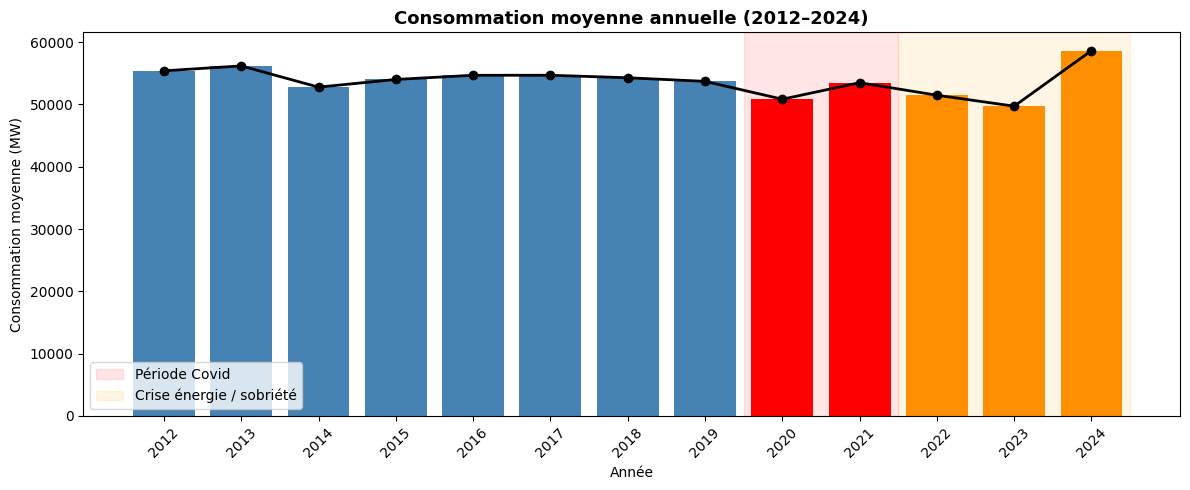

In [111]:
import seaborn as sns

conso_annuelle = df_E.groupby("year")["Consommation"].mean()

plt.figure(figsize=(12, 5))
bars = plt.bar(conso_annuelle.index, conso_annuelle.values, color=[
    "steelblue" if y <= 2019 else
    "red"       if y in [2020, 2021] else
    "darkorange"
    for y in conso_annuelle.index
])

# Ligne de tendance
plt.plot(conso_annuelle.index, conso_annuelle.values,
         color="black", linewidth=2, marker="o", zorder=5)

# Annotations des zones
plt.axvspan(2019.5, 2021.5, alpha=0.1, color="red",    label="Période Covid")
plt.axvspan(2021.5, 2024.5, alpha=0.1, color="orange", label="Crise énergie / sobriété")

plt.title("Consommation moyenne annuelle (2012–2024)", fontsize=13, fontweight="bold")
plt.xlabel("Année")
plt.ylabel("Consommation moyenne (MW)")
plt.xticks(conso_annuelle.index, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

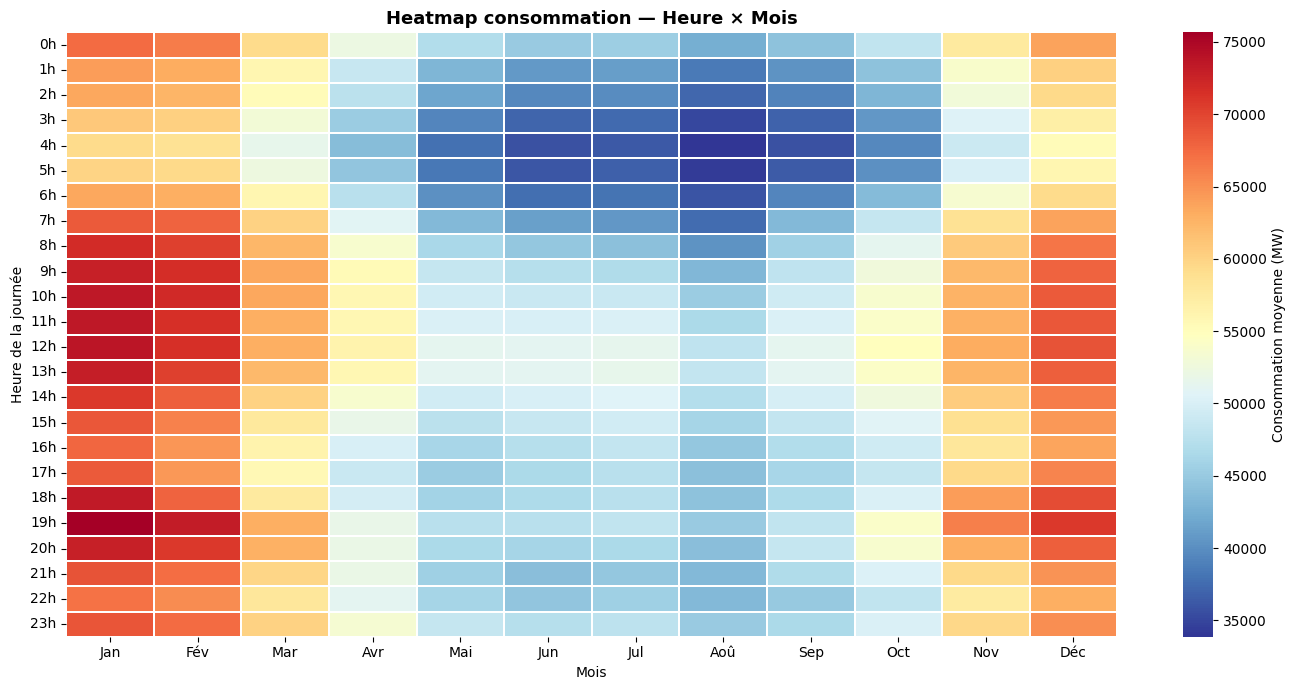

In [112]:
# Tableau croisé : ligne = heure, colonne = mois
heatmap_data = df_E.groupby(["hour", "month"])["Consommation"].mean().unstack()

plt.figure(figsize=(14, 7))
sns.heatmap(
    heatmap_data,
    cmap="RdYlBu_r",
    fmt=".0f",
    annot=False,
    linewidths=0.3,
    cbar_kws={"label": "Consommation moyenne (MW)"},
    xticklabels=["Jan","Fév","Mar","Avr","Mai","Jun",
                 "Jul","Aoû","Sep","Oct","Nov","Déc"],
    yticklabels=[f"{h}h" for h in range(24)]
)

plt.title("Heatmap consommation — Heure × Mois", fontsize=13, fontweight="bold")
plt.xlabel("Mois")
plt.ylabel("Heure de la journée")
plt.tight_layout()
plt.show()

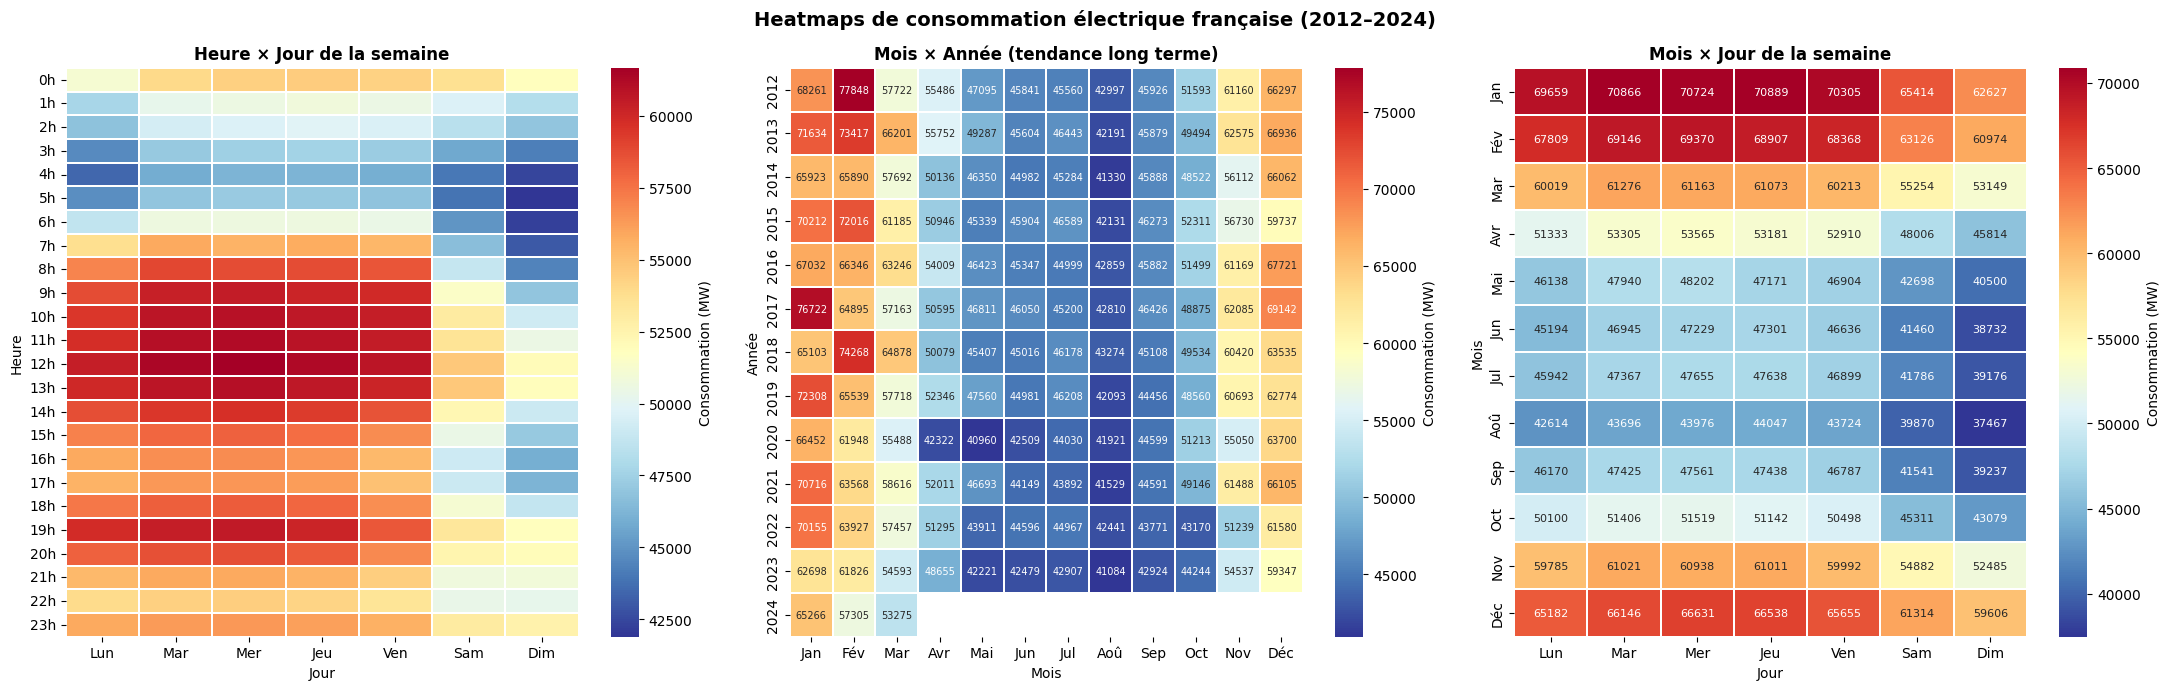

In [121]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# --- Heatmap 1 : Heure x Jour de la semaine ---
hm1 = df_E.groupby(["hour", "day_of_week"])["Consommation"].mean().unstack()
hm1.columns = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]

sns.heatmap(
    hm1, ax=axes[0], cmap="RdYlBu_r", annot=False,
    linewidths=0.3,
    cbar_kws={"label": "Consommation (MW)"},
    yticklabels=[f"{h}h" for h in range(24)]
)
axes[0].set_title("Heure × Jour de la semaine", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Jour")
axes[0].set_ylabel("Heure")

# --- Heatmap 2 : Mois x Année ---
hm2 = df_E.groupby(["year", "month"])["Consommation"].mean().unstack()
hm2.columns = ["Jan","Fév","Mar","Avr","Mai","Jun",
               "Jul","Aoû","Sep","Oct","Nov","Déc"]

sns.heatmap(
    hm2, ax=axes[1], cmap="RdYlBu_r", annot=True, fmt=".0f",
    linewidths=0.3, annot_kws={"size": 7},
    cbar_kws={"label": "Consommation (MW)"}
)
axes[1].set_title("Mois × Année (tendance long terme)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("Année")

# --- Heatmap 3 : Mois x Jour de la semaine ---
hm3 = df_E.groupby(["month", "day_of_week"])["Consommation"].mean().unstack()
hm3.index   = ["Jan","Fév","Mar","Avr","Mai","Jun",
                "Jul","Aoû","Sep","Oct","Nov","Déc"]
hm3.columns = ["Lun","Mar","Mer","Jeu","Ven","Sam","Dim"]

sns.heatmap(
    hm3, ax=axes[2], cmap="RdYlBu_r", annot=True, fmt=".0f",
    linewidths=0.3, annot_kws={"size": 8},
    cbar_kws={"label": "Consommation (MW)"}
)
axes[2].set_title("Mois × Jour de la semaine", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Jour")
axes[2].set_ylabel("Mois")

plt.suptitle("Heatmaps de consommation électrique française (2012–2024)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [122]:
# Ajout de la variable saison
def get_saison(month):
    if month in [12, 1, 2]:
        return "Hiver"
    elif month in [3, 4, 5]:
        return "Printemps"
    elif month in [6, 7, 8]:
        return "Été"
    else:
        return "Automne"

df_E["saison"] = df_E["month"].apply(get_saison)
print("Saisons créées ✅")

Saisons créées ✅


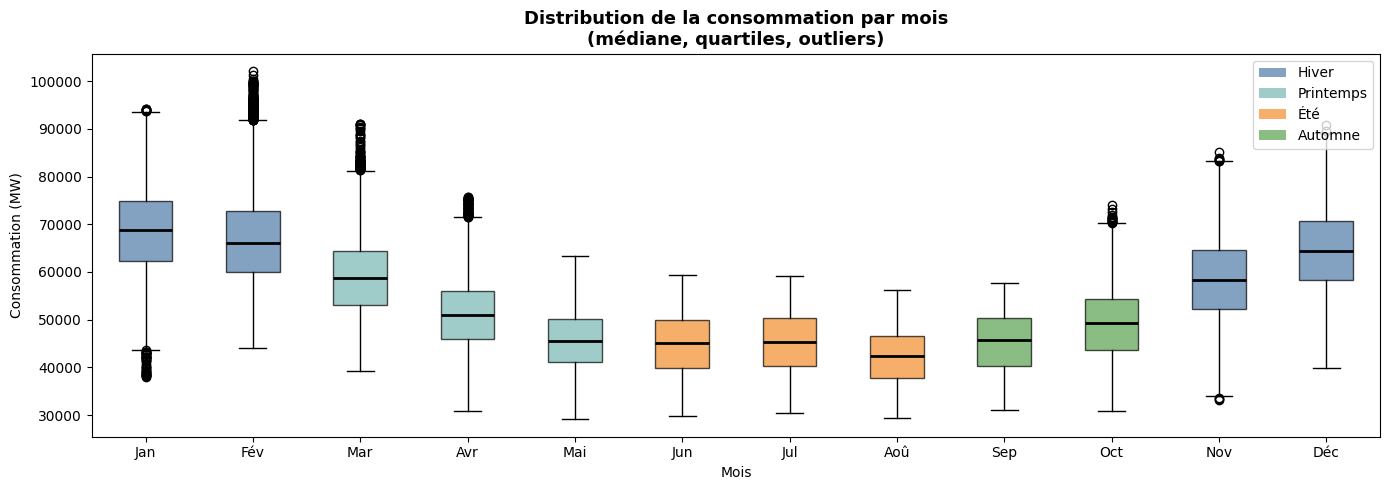

In [123]:
# --- Graphique 1 : Boxplot par mois ---
fig, ax = plt.subplots(figsize=(14, 5))

mois_labels = ["Jan","Fév","Mar","Avr","Mai","Jun",
               "Jul","Aoû","Sep","Oct","Nov","Déc"]

data_boxplot = [df_E[df_E["month"] == m]["Consommation"].values for m in range(1, 13)]

bp = ax.boxplot(data_boxplot, patch_artist=True, notch=False,
                medianprops=dict(color="black", linewidth=2))

colors_box = ["#4e79a7","#4e79a7","#76b7b2","#76b7b2","#76b7b2",
              "#f28e2b","#f28e2b","#f28e2b","#59a14f","#59a14f",
              "#4e79a7","#4e79a7"]
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(mois_labels)
ax.set_title("Distribution de la consommation par mois\n(médiane, quartiles, outliers)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("Consommation (MW)")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4e79a7", alpha=0.7, label="Hiver"),
    Patch(facecolor="#76b7b2", alpha=0.7, label="Printemps"),
    Patch(facecolor="#f28e2b", alpha=0.7, label="Été"),
    Patch(facecolor="#59a14f", alpha=0.7, label="Automne"),
]
ax.legend(handles=legend_elements, loc="upper right")
plt.tight_layout()
plt.show()

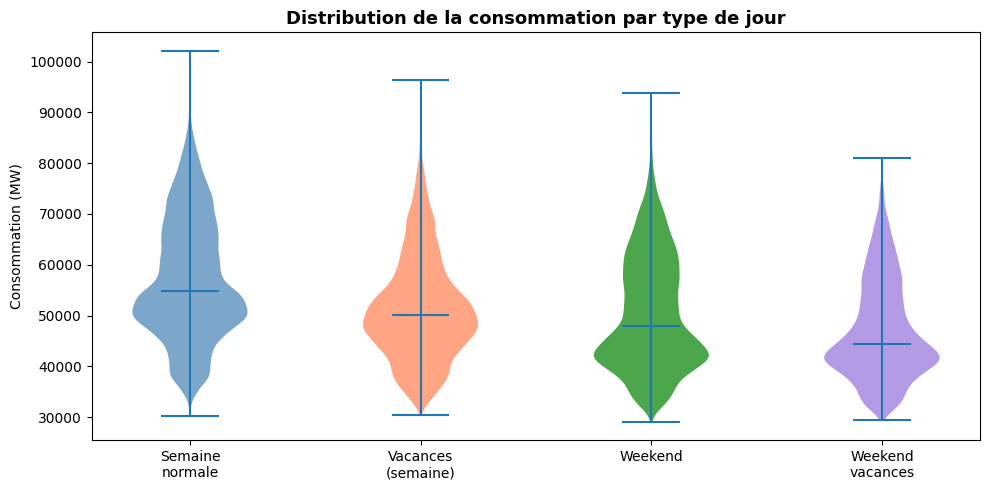

In [124]:
# --- Graphique 2 : Violin plot ---
fig, ax = plt.subplots(figsize=(10, 5))

data_violin = [
    df_E[df_E["type_jour"] == t]["Consommation"].values
    for t in ["Semaine normale", "Vacances (semaine)", "Weekend", "Weekend vacances"]
]

parts = ax.violinplot(data_violin, positions=[1, 2, 3, 4],
                      showmedians=True, showextrema=True)

colors_violin = ["steelblue", "coral", "green", "mediumpurple"]
for pc, color in zip(parts["bodies"], colors_violin):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(["Semaine\nnormale", "Vacances\n(semaine)",
                    "Weekend", "Weekend\nvacances"])
ax.set_title("Distribution de la consommation par type de jour",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Consommation (MW)")
plt.tight_layout()
plt.show()

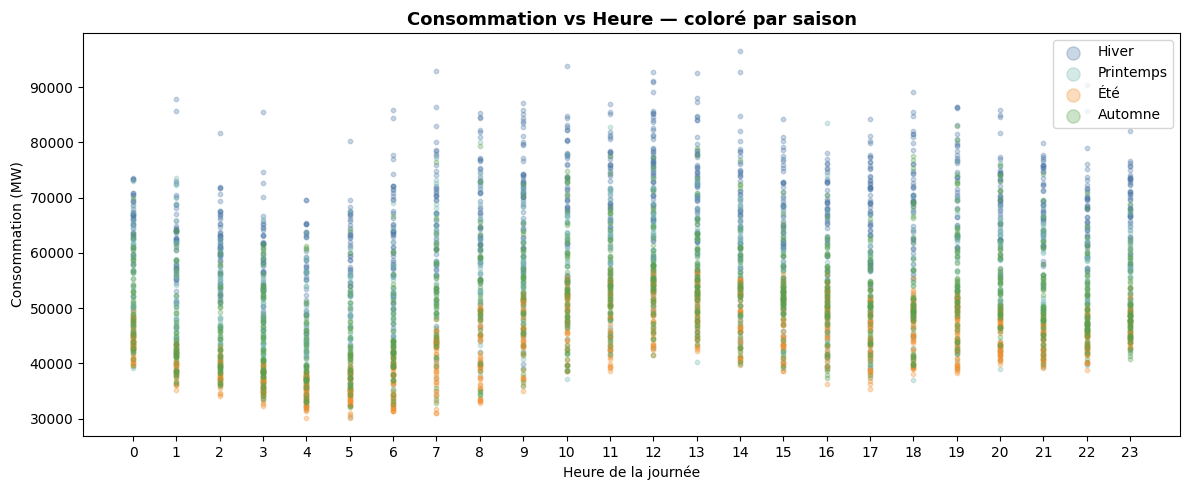

In [125]:
# --- Graphique 3 : Scatter plot heure vs conso coloré par saison ---
fig, ax = plt.subplots(figsize=(12, 5))

colors_saison = {
    "Hiver"     : "#4e79a7",
    "Printemps" : "#76b7b2",
    "Été"       : "#f28e2b",
    "Automne"   : "#59a14f"
}

# Échantillon pour ne pas surcharger le graphique
df_sample = df_E.sample(n=5000, random_state=42)

for saison, color in colors_saison.items():
    subset = df_sample[df_sample["saison"] == saison]
    ax.scatter(subset["hour"], subset["Consommation"],
               color=color, alpha=0.3, s=10, label=saison)

ax.set_title("Consommation vs Heure — coloré par saison",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Heure de la journée")
ax.set_ylabel("Consommation (MW)")
ax.set_xticks(range(0, 24))
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

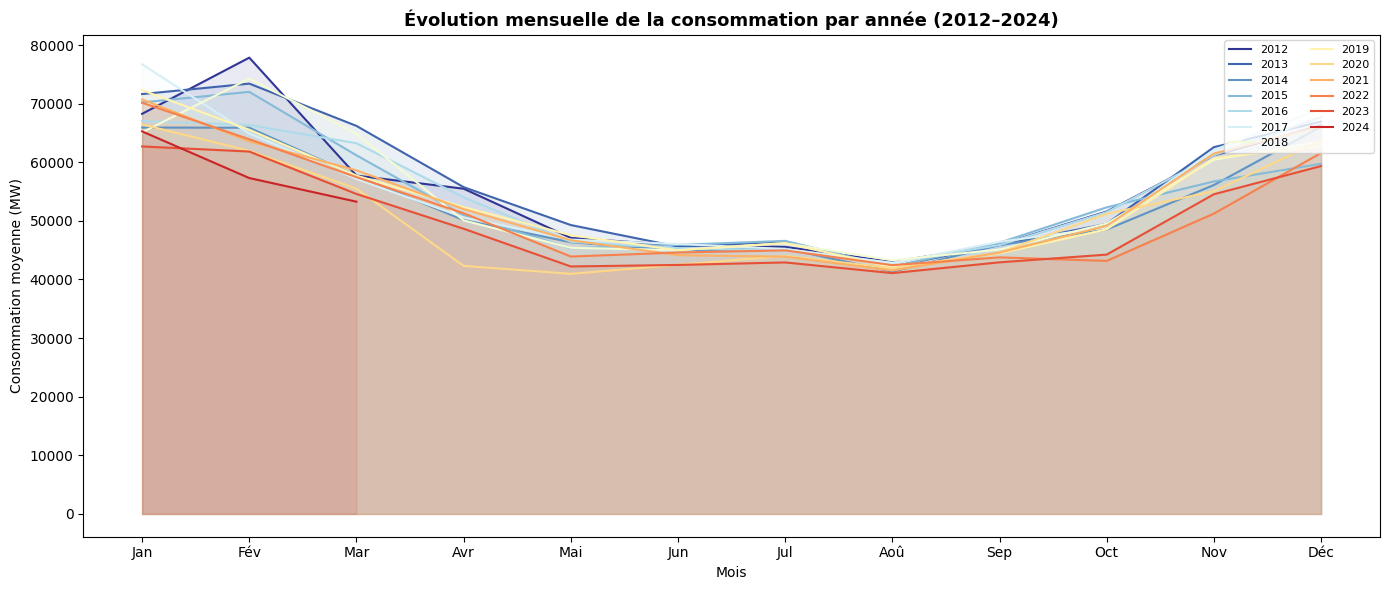

In [126]:
# --- Graphique 4 : Graphique en aires évolution mensuelle par année ---
fig, ax = plt.subplots(figsize=(14, 6))

conso_mois_annee = df_E.groupby(["year", "month"])["Consommation"].mean().unstack(0)

cmap = plt.cm.RdYlBu_r
colors_years = [cmap(i / len(conso_mois_annee.columns))
                for i in range(len(conso_mois_annee.columns))]

for i, year in enumerate(conso_mois_annee.columns):
    ax.plot(range(1, 13), conso_mois_annee[year],
            color=colors_years[i], linewidth=1.5, label=str(year))
    ax.fill_between(range(1, 13), conso_mois_annee[year],
                    alpha=0.1, color=colors_years[i])

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Fév","Mar","Avr","Mai","Jun",
                    "Jul","Aoû","Sep","Oct","Nov","Déc"])
ax.set_title("Évolution mensuelle de la consommation par année (2012–2024)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("Consommation moyenne (MW)")
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

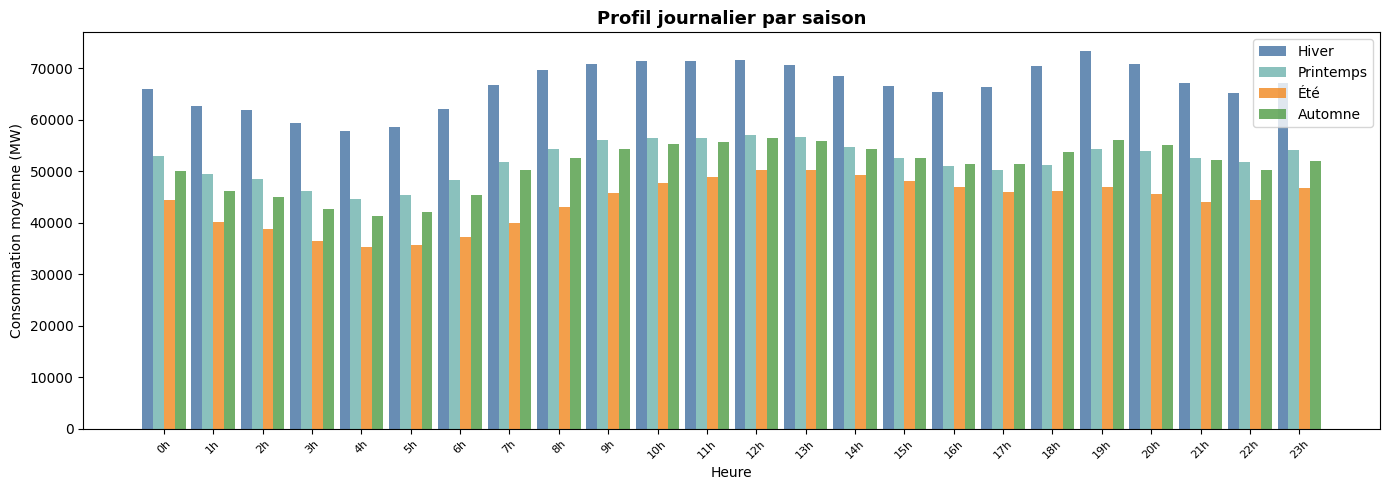

In [127]:
# --- Graphique 5 : Barplot profil journalier par saison ---
fig, ax = plt.subplots(figsize=(14, 5))

conso_heure_saison = df_E.groupby(["saison", "hour"])["Consommation"].mean().unstack(0)

x = np.arange(24)
width = 0.22
saisons = ["Hiver", "Printemps", "Été", "Automne"]
colors_s = ["#4e79a7", "#76b7b2", "#f28e2b", "#59a14f"]
offsets  = [-1.5, -0.5, 0.5, 1.5]

for saison, color, offset in zip(saisons, colors_s, offsets):
    ax.bar(x + offset * width, conso_heure_saison[saison],
           width=width, color=color, alpha=0.85, label=saison)

ax.set_xticks(x)
ax.set_xticklabels([f"{h}h" for h in range(24)], rotation=45, fontsize=8)
ax.set_title("Profil journalier par saison",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Heure")
ax.set_ylabel("Consommation moyenne (MW)")
ax.legend()
plt.tight_layout()
plt.show()

In [114]:
from vacances_scolaires_france import SchoolHolidayDates

hf = SchoolHolidayDates()

# On génère toutes les dates de vacances pour 2012-2024
# Zone C = Paris (la plus représentative pour la conso nationale)
vacances = set()
for year in range(2012, 2025):
    for date, info in hf.holidays_for_year_and_zone(year, "C").items():
        vacances.add(date)

print(f"{len(vacances)} jours de vacances trouvés")
print("Exemples :", list(vacances)[:5])

1607 jours de vacances trouvés
Exemples : [datetime.date(2021, 7, 6), datetime.date(2018, 7, 24), datetime.date(2020, 1, 2), datetime.date(2021, 8, 25), datetime.date(2020, 2, 12)]


In [115]:
# On ajoute la variable is_vacances au DataFrame
df_E["date_only"] = df_E["datetime"].dt.date
df_E["is_vacances"] = df_E["date_only"].isin(vacances).astype(int)

# Vérification
print("Répartition :")
print(df_E["is_vacances"].value_counts())
print(f"\nProportion vacances : {df_E['is_vacances'].mean()*100:.1f}%")

Répartition :
is_vacances
0    142464
1     72288
Name: count, dtype: int64

Proportion vacances : 33.7%


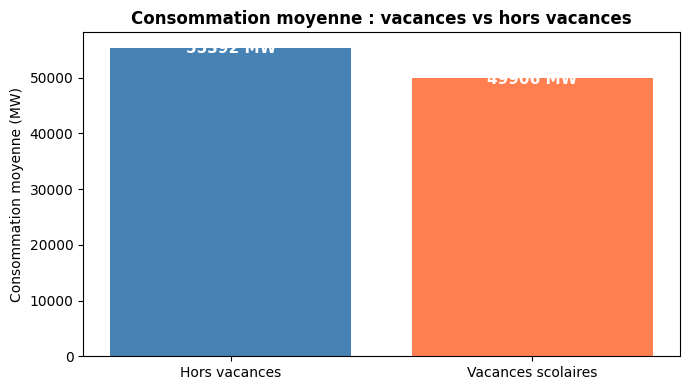

Différence : 5486 MW de moins pendant les vacances
Soit 9.9% de réduction


In [116]:
# Visualisation : conso moyenne vacances vs hors vacances
conso_vac = df_E.groupby("is_vacances")["Consommation"].mean()

plt.figure(figsize=(7, 4))
plt.bar(["Hors vacances", "Vacances scolaires"],
        conso_vac.values,
        color=["steelblue", "coral"])
for i, v in enumerate(conso_vac.values):
    plt.text(i, v - 1000, f"{v:.0f} MW", ha="center",
             fontsize=11, fontweight="bold", color="white")

plt.title("Consommation moyenne : vacances vs hors vacances", fontweight="bold")
plt.ylabel("Consommation moyenne (MW)")
plt.tight_layout()
plt.show()

diff = conso_vac[0] - conso_vac[1]
print(f"Différence : {diff:.0f} MW de moins pendant les vacances")
print(f"Soit {diff/conso_vac[0]*100:.1f}% de réduction")

Étape 6 — Préparation du split temporel


On coupe les données dans le temps : 
- Entraînement : 2012–2021
- Test : 2022–2024

On ne mélange PAS aléatoirement car les données sont 
chronologiques. Un split aléatoire laisserait le modèle 
"voir le futur" pendant l'entraînement, ce qui fausserait 
les performances.

In [75]:
features = ["hour", "day_of_week", "month", "day", "year", "is_weekend"]
X = df[features]
y = df["Consommation"]

train_mask = df["year"] <= 2021
test_mask  = df["year"] >= 2022

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Entraînement : {len(X_train):,} lignes ({X_train['year'].min()}–{X_train['year'].max()})")
print(f"Test         : {len(X_test):,} lignes ({X_test['year'].min()}–{X_test['year'].max()})")

Entraînement : 175,344 lignes (2012–2021)
Test         : 39,408 lignes (2022–2024)


Étape 7 — Modèle 1 : Régression linéaire

Modèle 1 : Régression linéaire
Le modèle le plus simple. Il cherche une combinaison linéaire 
des features pour prédire la consommation.
Avantages : rapide, interprétable
Limites : ne capte pas les relations non-linéaires

Métriques :
- RMSE : erreur moyenne en MW (plus c'est petit, mieux c'est)
- R²   : proportion de variance expliquée (1 = parfait, 0 = inutile)

In [76]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("=== Régression linéaire ===")
print(f"RMSE : {rmse_lr:.1f} MW")
print(f"R²   : {r2_lr:.4f}")

=== Régression linéaire ===
RMSE : 9833.6 MW
R²   : 0.1980


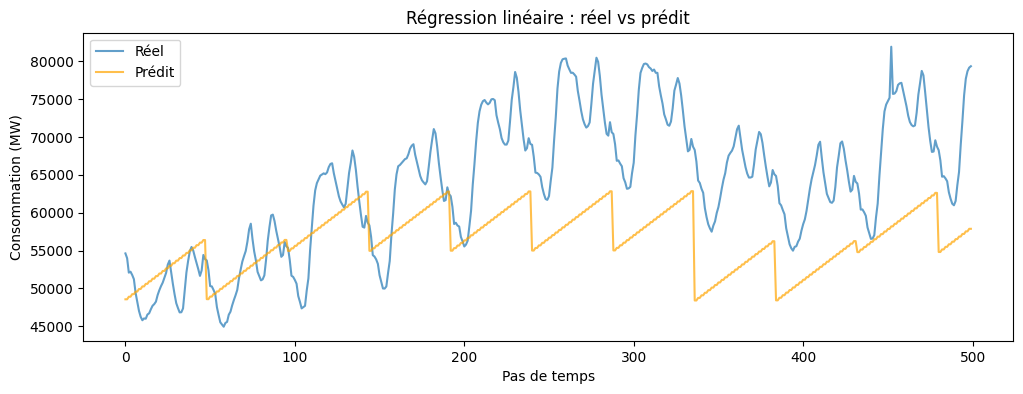

In [77]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:500], label="Réel", alpha=0.7)
plt.plot(y_pred_lr[:500], label="Prédit", alpha=0.7, color="orange")
plt.title("Régression linéaire : réel vs prédit")
plt.xlabel("Pas de temps")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.show()

Étape 8 — Modèle 2 : Random Forest

Modèle 2 : Random Forest
Ensemble d'arbres de décision capable de capter des relations 
non-linéaires et des interactions entre variables.
Ex : l'effet de l'heure EST différent selon le mois → 
la régression linéaire ne peut pas voir ça, le Random Forest si.
Attention : l'entraînement peut prendre 1-2 minutes.

In [78]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print(f"RMSE : {rmse_rf:.1f} MW")
print(f"R²   : {r2_rf:.4f}")

=== Random Forest ===
RMSE : 6917.6 MW
R²   : 0.6031


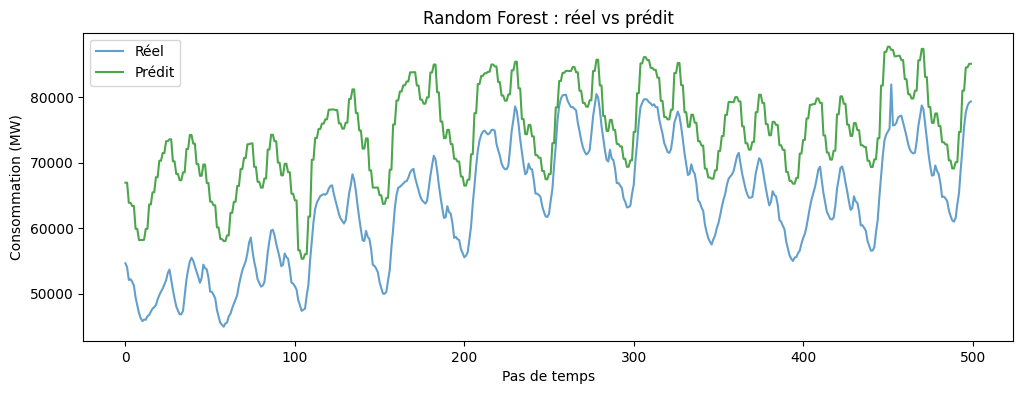

In [79]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:500], label="Réel", alpha=0.7)
plt.plot(y_pred_rf[:500], label="Prédit", alpha=0.7, color="green")
plt.title("Random Forest : réel vs prédit")
plt.xlabel("Pas de temps")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.show()

Nous allons maintenant prendre en compte les années avec des évenements qui peuvent avoir eu un impact sur la consommation (Covid, guerre en Ukraine, guerre en Iran...)

Modèle A — Sans les années Covid

Modèle A : Random Forest sans 2020-2021
On exclut les années Covid de l'entraînement car elles 
représentent une anomalie qui fausse ce que le modèle apprend 
comme "normal".

In [80]:
# On exclut 2020 et 2021 de l'entraînement
train_mask_A = (df["year"] <= 2019)
test_mask    = (df["year"] >= 2022)

X_train_A = df.loc[train_mask_A, features]
y_train_A = df.loc[train_mask_A, "Consommation"]
X_test_A  = df.loc[test_mask, features]
y_test_A  = df.loc[test_mask, "Consommation"]

print(f"Entraînement : {len(X_train_A):,} lignes ({X_train_A['year'].min()}–{X_train_A['year'].max()})")
print(f"Test         : {len(X_test_A):,} lignes ({X_test_A['year'].min()}–{X_test_A['year'].max()})")

Entraînement : 140,256 lignes (2012–2019)
Test         : 39,408 lignes (2022–2024)


In [81]:
rf_A = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_A.fit(X_train_A, y_train_A)

y_pred_A = rf_A.predict(X_test_A)

rmse_A = np.sqrt(mean_squared_error(y_test_A, y_pred_A))
r2_A   = r2_score(y_test_A, y_pred_A)

print("=== Modèle A : RF sans 2020-2021 ===")
print(f"RMSE : {rmse_A:.1f} MW")
print(f"R²   : {r2_A:.4f}")

=== Modèle A : RF sans 2020-2021 ===
RMSE : 6438.5 MW
R²   : 0.6562


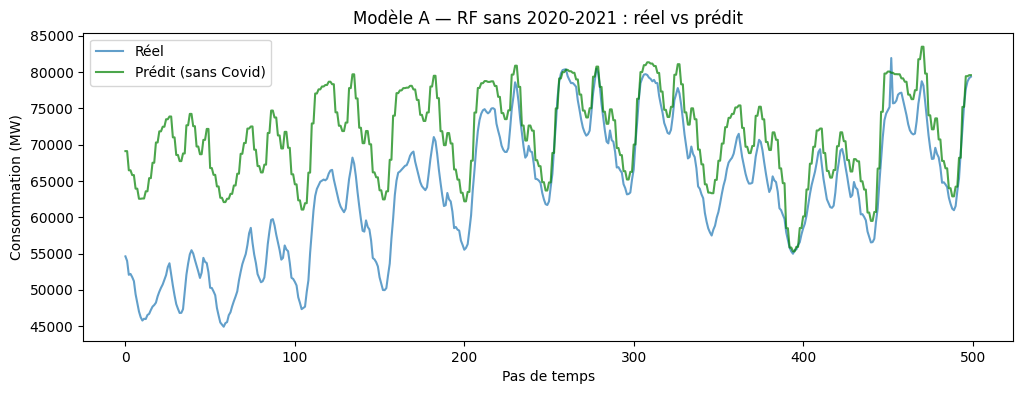

In [82]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_A.values[:500], label="Réel", alpha=0.7)
plt.plot(y_pred_A[:500], label="Prédit (sans Covid)", alpha=0.7, color="green")
plt.title("Modèle A — RF sans 2020-2021 : réel vs prédit")
plt.xlabel("Pas de temps")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.show()

Modèle B — Avec variable evenement

Modèle B : RF avec variable "evenement"
On ajoute une variable catégorielle qui encode les grandes 
périodes de rupture de consommation :
- 0 : période normale (2012-2019)
- 1 : Covid (2020-2021) → chute temporaire
- 2 : Crise énergétique + sobriété (2022-2024) → baisse structurelle
On pourrait ajouter d'autres événements si les données 
le permettaient (ex: guerre Iran).

In [83]:
# Ajout de la variable evenement sur tout le DataFrame
def encoder_evenement(year):
    if year in [2020, 2021]:
        return 1  # Covid
    elif year >= 2022:
        return 2  # Crise énergie / sobriété
    else:
        return 0  # Normal

df["evenement"] = df["year"].apply(encoder_evenement)

# Vérification
df.groupby("evenement")["year"].unique()

evenement
0    [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
1                                        [2020, 2021]
2                                  [2022, 2023, 2024]
Name: year, dtype: object

In [84]:
# Nouvelles features avec la variable evenement
features_B = ["hour", "day_of_week", "month", "day", "year", "is_weekend", "evenement"]

X_B = df[features_B]
y_B = df["Consommation"]

# Même split temporel : train 2012-2021, test 2022-2024
train_mask_B = df["year"] <= 2021
test_mask_B  = df["year"] >= 2022

X_train_B = X_B[train_mask_B]
y_train_B = y_B[train_mask_B]
X_test_B  = X_B[test_mask_B]
y_test_B  = y_B[test_mask_B]

print(f"Entraînement : {len(X_train_B):,} lignes")
print(f"Test         : {len(X_test_B):,} lignes")

Entraînement : 175,344 lignes
Test         : 39,408 lignes


In [85]:
rf_B = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_B.fit(X_train_B, y_train_B)

y_pred_B = rf_B.predict(X_test_B)

rmse_B = np.sqrt(mean_squared_error(y_test_B, y_pred_B))
r2_B   = r2_score(y_test_B, y_pred_B)

print("=== Modèle B : RF avec variable événement ===")
print(f"RMSE : {rmse_B:.1f} MW")
print(f"R²   : {r2_B:.4f}")

=== Modèle B : RF avec variable événement ===
RMSE : 6917.5 MW
R²   : 0.6031


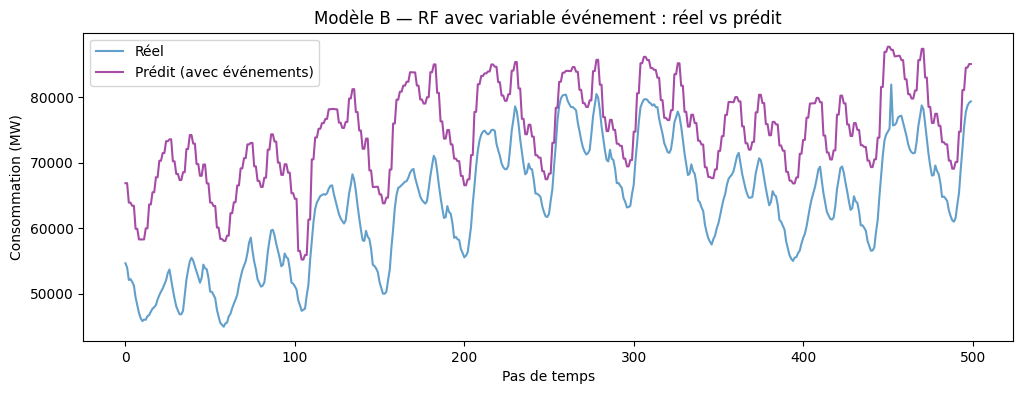

In [86]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_B.values[:500], label="Réel", alpha=0.7)
plt.plot(y_pred_B[:500], label="Prédit (avec événements)", alpha=0.7, color="purple")
plt.title("Modèle B — RF avec variable événement : réel vs prédit")
plt.xlabel("Pas de temps")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.show()

## Modèle C : RF avec variables de crise enrichies
On remplace la variable binaire evenement par 3 variables 
plus informatives calculées directement depuis les données :
- conso_moy_annee_prec : consommation moyenne de l'année précédente
- ecart_historique     : écart à la moyenne 2012-2019 pour ce mois/heure
- intensite_crise      : valeur continue entre 0 et 1 selon la période

In [87]:
# --- Variable 1 : consommation moyenne par année ---
conso_moy_par_annee = df.groupby("year")["Consommation"].mean()

# On décale d'un an pour avoir la moyenne de l'année PRÉCÉDENTE
conso_moy_par_annee_prec = conso_moy_par_annee.shift(1)
df["conso_moy_annee_prec"] = df["year"].map(conso_moy_par_annee_prec)

# --- Variable 2 : moyenne historique 2012-2019 par mois ET heure ---
df_normal = df[df["year"] <= 2019]
moy_historique = df_normal.groupby(["month", "hour"])["Consommation"].mean()
moy_historique.name = "moy_historique"
df = df.join(moy_historique, on=["month", "hour"])
df["ecart_historique"] = df["Consommation"] - df["moy_historique"]

# --- Variable 3 : intensité de crise progressive ---
def intensite_crise(year):
    if year <= 2019:
        return 0.0   # Période normale
    elif year == 2020:
        return 0.8   # Covid fort
    elif year == 2021:
        return 0.5   # Covid qui s'atténue
    elif year == 2022:
        return 0.9   # Crise énergie intense
    elif year == 2023:
        return 0.6   # Sobriété qui s'installe
    else:
        return 0.4   # Retour progressif

df["intensite_crise"] = df["year"].apply(intensite_crise)

# Vérification
df[["year", "conso_moy_annee_prec", "ecart_historique", "intensite_crise"]].drop_duplicates("year").sort_values("year")

,year,conso_moy_annee_prec,ecart_historique,intensite_crise
0,2012,NaN,-10323.929435,0.0
17568,2013,55396.961806,-7444.929435,0.0
35088,2014,56185.529852,-3978.929435,0.0
52608,2015,52779.499144,5855.070565,0.0
70128,2016,54012.877797,-8473.929435,0.0
87696,2017,54681.287739,7620.070565,0.0
105216,2018,54685.462043,-7511.929435,0.0
122736,2019,54283.219521,-4431.929435,0.0
140256,2020,53707.436301,-1570.929435,0.8
157824,2021,50840.467953,-1482.929435,0.5


In [88]:
# Nouvelles features enrichies
features_C = [
    "hour", "day_of_week", "month", "day", "year", "is_weekend",
    "conso_moy_annee_prec", "ecart_historique", "intensite_crise"
]

X_C = df[features_C]
y_C = df["Consommation"]

train_mask_C = df["year"] <= 2021
test_mask_C  = df["year"] >= 2022

X_train_C = X_C[train_mask_C].dropna()
y_train_C = y_C[X_train_C.index]
X_test_C  = X_C[test_mask_C].dropna()
y_test_C  = y_C[X_test_C.index]

print(f"Entraînement : {len(X_train_C):,} lignes")
print(f"Test         : {len(X_test_C):,} lignes")
print(f"\nFeatures utilisées : {features_C}")

Entraînement : 157,776 lignes
Test         : 39,408 lignes

Features utilisées : ['hour', 'day_of_week', 'month', 'day', 'year', 'is_weekend', 'conso_moy_annee_prec', 'ecart_historique', 'intensite_crise']


In [89]:
rf_C = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_C.fit(X_train_C, y_train_C)

y_pred_C = rf_C.predict(X_test_C)

rmse_C = np.sqrt(mean_squared_error(y_test_C, y_pred_C))
r2_C   = r2_score(y_test_C, y_pred_C)

print("=== Modèle C : RF variables enrichies ===")
print(f"RMSE : {rmse_C:.1f} MW")
print(f"R²   : {r2_C:.4f}")

=== Modèle C : RF variables enrichies ===
RMSE : 481.5 MW
R²   : 0.9981


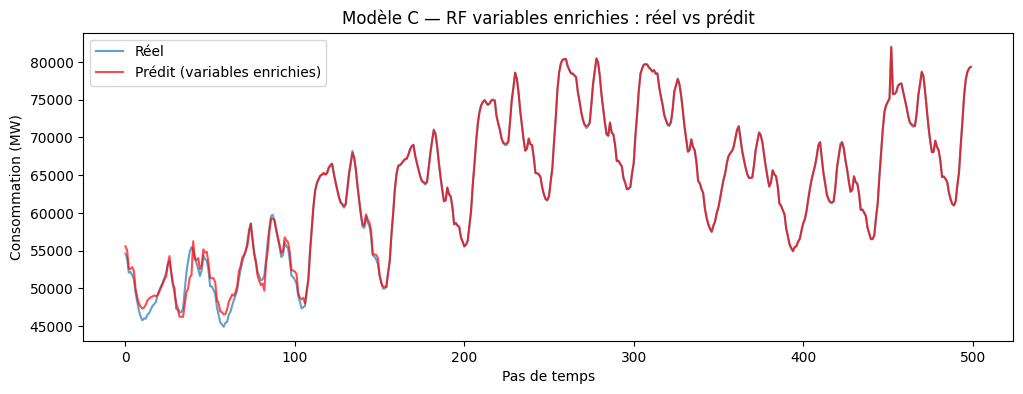

In [90]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_C.values[:500], label="Réel", alpha=0.7)
plt.plot(y_pred_C[:500], label="Prédit (variables enrichies)", alpha=0.7, color="red")
plt.title("Modèle C — RF variables enrichies : réel vs prédit")
plt.xlabel("Pas de temps")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.show()

## Modèle D : RF propre sans data leakage
On remplace ecart_historique (qui utilisait la conso réelle)
par des références historiques connues à l'avance :
- conso moyenne du même mois, l'année précédente
- conso moyenne de la même heure, l'année précédente
Ces variables simulent ce qu'un vrai système de prédiction 
aurait à disposition sans "tricher".


In [91]:
# Variable 1 : conso moyenne par mois ET année précédente
conso_mois_annee = df.groupby(["year", "month"])["Consommation"].mean()
conso_mois_annee = conso_mois_annee.reset_index()
conso_mois_annee.columns = ["year", "month", "conso_moy_mois"]

# On décale d'un an
conso_mois_annee["year_cible"] = conso_mois_annee["year"] + 1
ref_mois = conso_mois_annee[["year_cible", "month", "conso_moy_mois"]].rename(
    columns={"year_cible": "year", "conso_moy_mois": "conso_meme_mois_prec"}
)

df = df.merge(ref_mois, on=["year", "month"], how="left")

# Variable 2 : conso moyenne par heure ET année précédente
conso_heure_annee = df.groupby(["year", "hour"])["Consommation"].mean()
conso_heure_annee = conso_heure_annee.reset_index()
conso_heure_annee.columns = ["year", "hour", "conso_moy_heure"]

conso_heure_annee["year_cible"] = conso_heure_annee["year"] + 1
ref_heure = conso_heure_annee[["year_cible", "hour", "conso_moy_heure"]].rename(
    columns={"year_cible": "year", "conso_moy_heure": "conso_meme_heure_prec"}
)

df = df.merge(ref_heure, on=["year", "hour"], how="left")

# Vérification
df[["year", "month", "hour", "conso_meme_mois_prec", 
    "conso_meme_heure_prec", "conso_moy_annee_prec", 
    "intensite_crise"]].drop_duplicates("year").sort_values("year")

,year,month,hour,conso_meme_mois_prec,conso_meme_heure_prec,conso_moy_annee_prec,intensite_crise
0,2012,1,0,NaN,NaN,NaN,0.0
17568,2013,1,0,68261.475806,55265.259563,55396.961806,0.0
35088,2014,1,0,71633.961022,56172.813699,56185.529852,0.0
52608,2015,1,0,65923.247312,52928.628767,52779.499144,0.0
70128,2016,1,0,70211.567204,54269.976712,54012.877797,0.0
87696,2017,1,0,67031.502688,54969.178962,54681.287739,0.0
105216,2018,1,0,76722.452285,55034.539726,54685.462043,0.0
122736,2019,1,0,65102.593414,54262.280822,54283.219521,0.0
140256,2020,1,0,72308.372984,53611.601370,53707.436301,0.8
157824,2021,1,0,66451.825941,51060.728142,50840.467953,0.5


In [92]:
features_D = [
    "hour", "day_of_week", "month", "day", "year", "is_weekend",
    "intensite_crise",
    "conso_moy_annee_prec",
    "conso_meme_mois_prec",
    "conso_meme_heure_prec"
]

X_D = df[features_D]
y_D = df["Consommation"]

train_mask_D = df["year"] <= 2021
test_mask_D  = df["year"] >= 2022

X_train_D = X_D[train_mask_D].dropna()
y_train_D = y_D[X_train_D.index]
X_test_D  = X_D[test_mask_D].dropna()
y_test_D  = y_D[X_test_D.index]

print(f"Entraînement : {len(X_train_D):,} lignes")
print(f"Test         : {len(X_test_D):,} lignes")
print(f"\nFeatures : {features_D}")

Entraînement : 157,776 lignes
Test         : 39,408 lignes

Features : ['hour', 'day_of_week', 'month', 'day', 'year', 'is_weekend', 'intensite_crise', 'conso_moy_annee_prec', 'conso_meme_mois_prec', 'conso_meme_heure_prec']


In [93]:
rf_D = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_D.fit(X_train_D, y_train_D)

y_pred_D = rf_D.predict(X_test_D)

rmse_D = np.sqrt(mean_squared_error(y_test_D, y_pred_D))
r2_D   = r2_score(y_test_D, y_pred_D)

print("=== Modèle D : RF sans data leakage ===")
print(f"RMSE : {rmse_D:.1f} MW")
print(f"R²   : {r2_D:.4f}")

=== Modèle D : RF sans data leakage ===
RMSE : 5734.2 MW
R²   : 0.7273


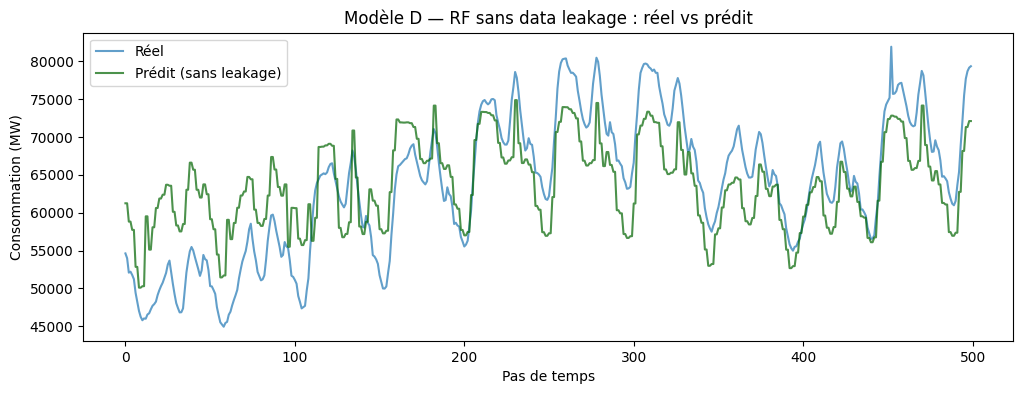

In [94]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_D.values[:500], label="Réel", alpha=0.7)
plt.plot(y_pred_D[:500], label="Prédit (sans leakage)", alpha=0.7, color="darkgreen")
plt.title("Modèle D — RF sans data leakage : réel vs prédit")
plt.xlabel("Pas de temps")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.show()

## Modèle E : RF écart propre sans data leakage
On remplace ecart_historique (qui utilisait la conso réelle)


In [95]:
fichiers = glob.glob("eCO2mix_RTE_Annuel-Definitif_*.xls")

dfs = []
for fichier in fichiers:
    df_temp = pd.read_csv(
        fichier, sep="\t", encoding="latin1",
        index_col=False, low_memory=False
    )
    dfs.append(df_temp)

df_E = pd.concat(dfs, ignore_index=True)

# --- Nettoyage ---
df_E = df_E[["Date", "Heures", "Consommation"]].copy()
df_E = df_E.dropna(subset=["Date", "Heures"])
df_E["Consommation"] = pd.to_numeric(df_E["Consommation"], errors="coerce")
df_E = df_E.dropna(subset=["Consommation"]).reset_index(drop=True)

# --- Feature engineering de base ---
df_E["datetime"]    = pd.to_datetime(df_E["Date"] + " " + df_E["Heures"])
df_E["hour"]        = df_E["datetime"].dt.hour
df_E["day_of_week"] = df_E["datetime"].dt.dayofweek
df_E["month"]       = df_E["datetime"].dt.month
df_E["day"]         = df_E["datetime"].dt.day
df_E["year"]        = df_E["datetime"].dt.year
df_E["is_weekend"]  = (df_E["day_of_week"] >= 5).astype(int)

# --- intensite_crise ---
def intensite_crise(year):
    if year <= 2019:
        return 0.0
    elif year == 2020:
        return 0.8
    elif year == 2021:
        return 0.5
    elif year == 2022:
        return 0.9
    elif year == 2023:
        return 0.6
    else:
        return 0.4

df_E["intensite_crise"] = df_E["year"].apply(intensite_crise)

# --- conso_moy_annee_prec ---
conso_moy_par_annee = df_E.groupby("year")["Consommation"].mean()
df_E["conso_moy_annee_prec"] = df_E["year"].map(conso_moy_par_annee.shift(1))

# --- conso_meme_mois_prec ---
conso_mois = df_E.groupby(["year", "month"])["Consommation"].mean().reset_index()
conso_mois.columns = ["year", "month", "conso_meme_mois_prec"]
conso_mois["year"] = conso_mois["year"] + 1
df_E = df_E.merge(conso_mois, on=["year", "month"], how="left")

# --- conso_meme_heure_prec ---
conso_heure = df_E.groupby(["year", "hour"])["Consommation"].mean().reset_index()
conso_heure.columns = ["year", "hour", "conso_meme_heure_prec"]
conso_heure["year"] = conso_heure["year"] + 1
df_E = df_E.merge(conso_heure, on=["year", "hour"], how="left")

# --- ecart_hist_propre (calculé UNIQUEMENT sur le train 2012-2021) ---
df_train_ref = df_E[df_E["year"] <= 2021]
moy_hist = df_train_ref.groupby(["month", "hour"])["Consommation"].mean()
moy_hist.name = "moy_hist"
df_E = df_E.join(moy_hist, on=["month", "hour"])
df_E["ecart_hist_propre"] = df_E["Consommation"] - df_E["moy_hist"]

print("Colonnes disponibles :")
print(df_E.columns.tolist())
print(f"\nDimensions : {df_E.shape}")

Colonnes disponibles :
['Date', 'Heures', 'Consommation', 'datetime', 'hour', 'day_of_week', 'month', 'day', 'year', 'is_weekend', 'intensite_crise', 'conso_moy_annee_prec', 'conso_meme_mois_prec', 'conso_meme_heure_prec', 'moy_hist', 'ecart_hist_propre']

Dimensions : (214752, 16)


In [96]:
features_E = [
    "hour", "day_of_week", "month", "day", "year", "is_weekend",
    "intensite_crise",
    "conso_moy_annee_prec",
    "conso_meme_mois_prec",
    "conso_meme_heure_prec",
    "ecart_hist_propre"
]

X_E = df_E[features_E]
y_E = df_E["Consommation"]

train_mask_E = df_E["year"] <= 2021
test_mask_E  = df_E["year"] >= 2022

X_train_E = X_E[train_mask_E].dropna()
y_train_E = y_E[X_train_E.index]
X_test_E  = X_E[test_mask_E].dropna()
y_test_E  = y_E[X_test_E.index]

print(f"Entraînement : {len(X_train_E):,} lignes ({X_train_E['year'].min()}–{X_train_E['year'].max()})")
print(f"Test         : {len(X_test_E):,} lignes ({X_test_E['year'].min()}–{X_test_E['year'].max()})")

Entraînement : 157,776 lignes (2013–2021)
Test         : 39,408 lignes (2022–2024)


In [97]:
rf_E = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_E.fit(X_train_E, y_train_E)

y_pred_E = rf_E.predict(X_test_E)

rmse_E = np.sqrt(mean_squared_error(y_test_E, y_pred_E))
r2_E   = r2_score(y_test_E, y_pred_E)

print("=== Modèle E : RF écart historique propre ===")
print(f"RMSE : {rmse_E:.1f} MW")
print(f"R²   : {r2_E:.4f}")

=== Modèle E : RF écart historique propre ===
RMSE : 2428.8 MW
R²   : 0.9511


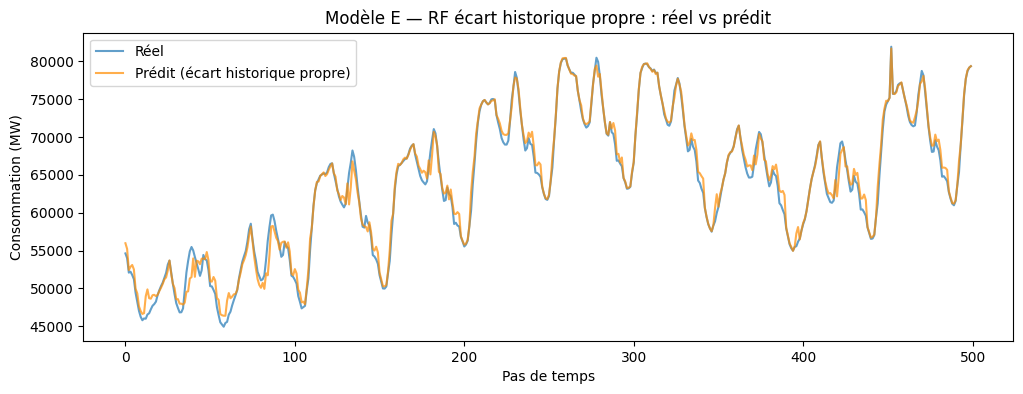

In [98]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_E.values[:500], label="Réel", alpha=0.7)
plt.plot(y_pred_E[:500], label="Prédit (écart historique propre)",
         alpha=0.7, color="darkorange")
plt.title("Modèle E — RF écart historique propre : réel vs prédit")
plt.xlabel("Pas de temps")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.show()

In [117]:
# Modèle E2 : RF écart historique propre + vacances
features_E2 = features_E + ["is_vacances"]

X_E2 = df_E[features_E2]
y_E2 = df_E["Consommation"]

X_train_E2 = X_E2[train_mask_E].dropna()
y_train_E2 = y_E2[X_train_E2.index]
X_test_E2  = X_E2[test_mask_E].dropna()
y_test_E2  = y_E2[X_test_E2.index]

rf_E2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_E2.fit(X_train_E2, y_train_E2)
y_pred_E2 = rf_E2.predict(X_test_E2)

rmse_E2 = np.sqrt(mean_squared_error(y_test_E2, y_pred_E2))
r2_E2   = r2_score(y_test_E2, y_pred_E2)

print("=== Modèle E2 : RF + vacances ===")
print(f"RMSE : {rmse_E2:.1f} MW  (avant : {rmse_E:.1f})")
print(f"R²   : {r2_E2:.4f}      (avant : {r2_E:.4f})")

=== Modèle E2 : RF + vacances ===
RMSE : 2416.4 MW  (avant : 2428.8)
R²   : 0.9516      (avant : 0.9511)


## Modèle F : XGBoost
XGBoost (Extreme Gradient Boosting) construit des arbres en 
séquence : chaque arbre corrige les erreurs du précédent.
C'est la différence clé avec le Random Forest qui construit 
ses arbres en parallèle indépendamment.

On utilise les mêmes features propres que le modèle E 
(sans data leakage) pour comparer à armes égales.

In [105]:
# Même features et split que le modèle E
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_E, y_train_E)

y_pred_F = xgb.predict(X_test_E)

rmse_F = np.sqrt(mean_squared_error(y_test_E, y_pred_F))
r2_F   = r2_score(y_test_E, y_pred_F)

print("=== Modèle F : XGBoost ===")
print(f"RMSE : {rmse_F:.1f} MW")
print(f"R²   : {r2_F:.4f}")

=== Modèle F : XGBoost ===
RMSE : 2614.2 MW
R²   : 0.9433


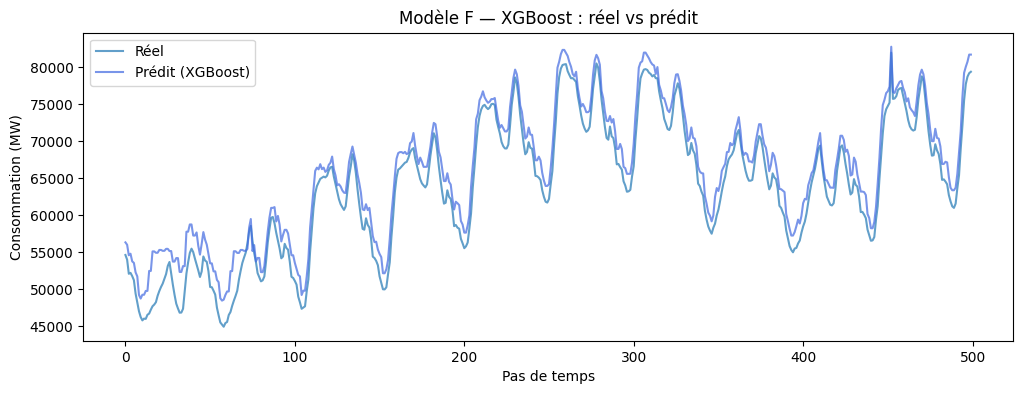

In [106]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_E.values[:500], label="Réel", alpha=0.7)
plt.plot(y_pred_F[:500], label="Prédit (XGBoost)",
         alpha=0.7, color="royalblue")
plt.title("Modèle F — XGBoost : réel vs prédit")
plt.xlabel("Pas de temps")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.show()

In [118]:
# Modèle F2 : XGBoost + vacances
features_F2 = features_E + ["is_vacances"]

X_F2 = df_E[features_F2]
y_F2 = df_E["Consommation"]

X_train_F2 = X_F2[train_mask_E].dropna()
y_train_F2 = y_F2[X_train_F2.index]
X_test_F2  = X_F2[test_mask_E].dropna()
y_test_F2  = y_F2[X_test_F2.index]

xgb_F2 = XGBRegressor(n_estimators=100, learning_rate=0.1,
                       max_depth=6, random_state=42, n_jobs=-1)
xgb_F2.fit(X_train_F2, y_train_F2)
y_pred_F2 = xgb_F2.predict(X_test_F2)

rmse_F2 = np.sqrt(mean_squared_error(y_test_F2, y_pred_F2))
r2_F2   = r2_score(y_test_F2, y_pred_F2)

print("=== Modèle F2 : XGBoost + vacances ===")
print(f"RMSE : {rmse_F2:.1f} MW  (avant : {rmse_F:.1f})")
print(f"R²   : {r2_F2:.4f}      (avant : {r2_F:.4f})")

=== Modèle F2 : XGBoost + vacances ===
RMSE : 2654.8 MW  (avant : 2614.2)
R²   : 0.9415      (avant : 0.9433)


C:\Users\Fefe\AppData\Local\Temp\ipykernel_29416\3692979639.py:23: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Fefe\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


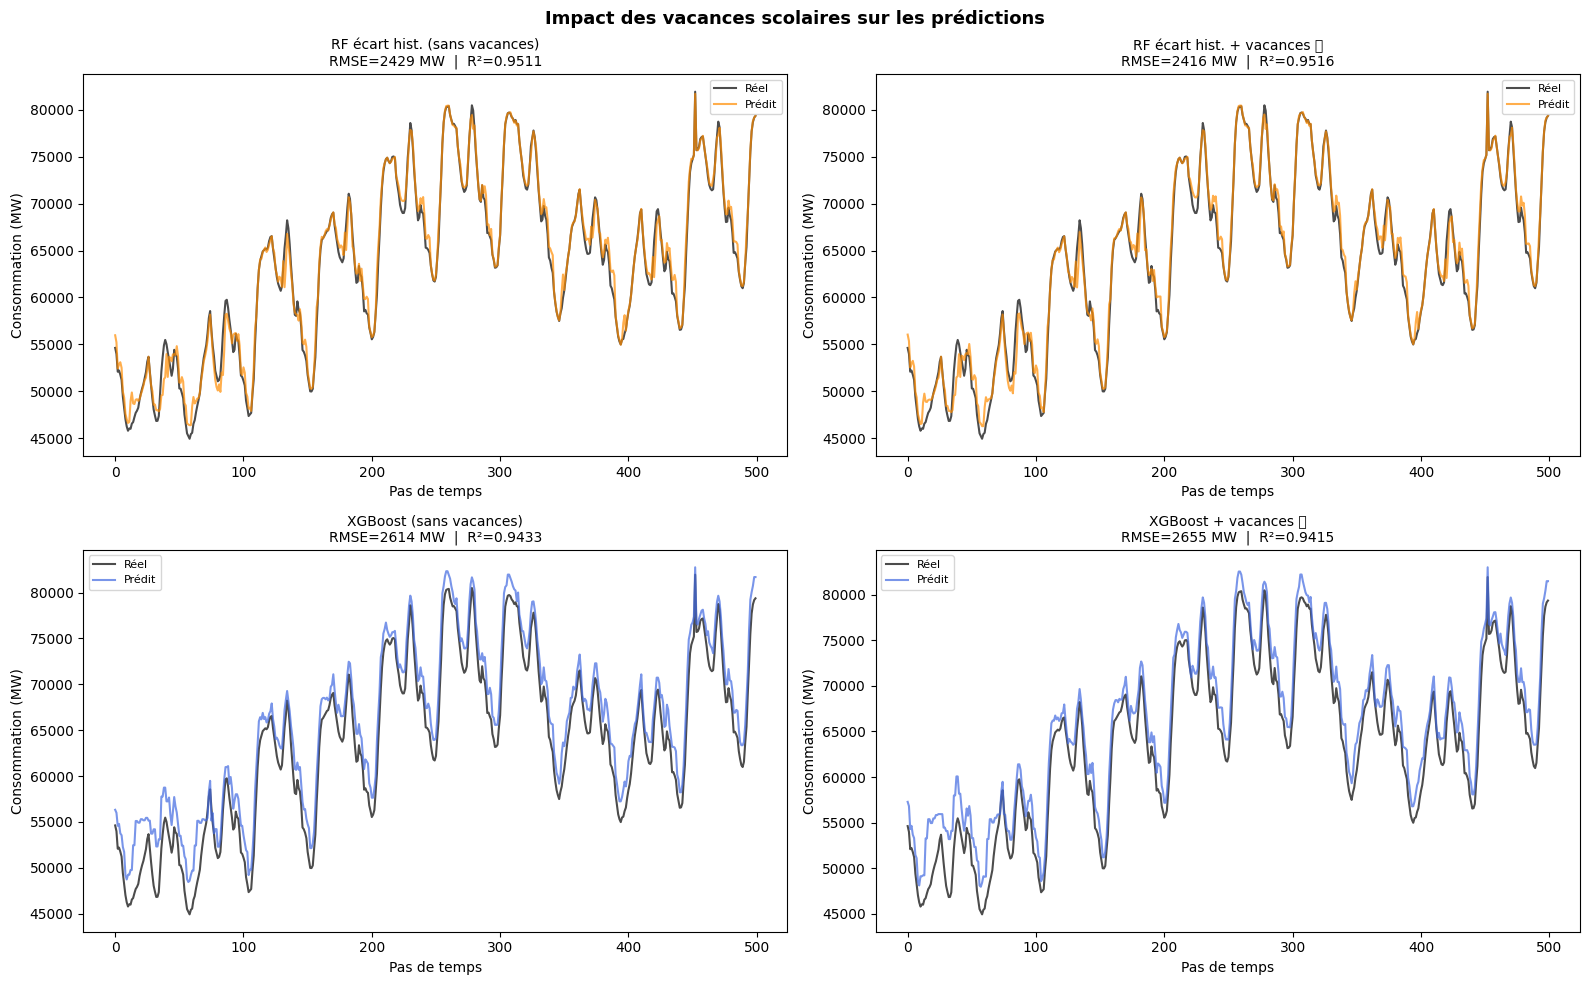

In [119]:
# Comparaison E vs E2 et F vs F2
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

modeles_vac = [
    (y_test_E2.values, y_pred_E,  "RF écart hist. (sans vacances)",  "darkorange", rmse_E,  r2_E),
    (y_test_E2.values, y_pred_E2, "RF écart hist. + vacances ✅",    "darkorange", rmse_E2, r2_E2),
    (y_test_E2.values, y_pred_F,  "XGBoost (sans vacances)",         "royalblue",  rmse_F,  r2_F),
    (y_test_F2.values, y_pred_F2, "XGBoost + vacances ✅",           "royalblue",  rmse_F2, r2_F2),
]

sample = 500
for i, (y_reel, y_pred, titre, couleur, rmse_val, r2_val) in enumerate(modeles_vac):
    axes[i].plot(y_reel[:sample], label="Réel", alpha=0.7, color="black")
    axes[i].plot(y_pred[:sample], label="Prédit", alpha=0.7, color=couleur)
    axes[i].set_title(f"{titre}\nRMSE={rmse_val:.0f} MW  |  R²={r2_val:.4f}", fontsize=10)
    axes[i].set_xlabel("Pas de temps")
    axes[i].set_ylabel("Consommation (MW)")
    axes[i].legend(fontsize=8)

plt.suptitle("Impact des vacances scolaires sur les prédictions",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Comparaison finale de tous les modèles

In [107]:
comparaison = pd.DataFrame({
    "Modèle" : [
        "Régression linéaire",
        "RF complet (2012-2021)",
        "RF sans Covid",
        "RF variable événement",
        "RF variables enrichies (leakage ⚠️)",
        "RF sans data leakage ✅",
        "RF écart historique propre",
        "XGBoost"
    ],
    "RMSE (MW)" : [
        round(rmse_lr, 1),
        round(rmse_rf, 1),
        round(rmse_A, 1),
        round(rmse_B, 1),
        round(rmse_C, 1),
        round(rmse_D, 1),
        round(rmse_E, 1),
        round(rmse_F, 1)
    ],
    "R²" : [
        round(r2_lr, 4),
        round(r2_rf, 4),
        round(r2_A, 4),
        round(r2_B, 4),
        round(r2_C, 4),
        round(r2_D, 4),
        round(r2_E, 4),
        round(r2_F, 4),
    ]
})
print(comparaison.to_string(index=False))

                             Modèle  RMSE (MW)     R²
                Régression linéaire     9833.6 0.1980
             RF complet (2012-2021)     6917.6 0.6031
                      RF sans Covid     6438.5 0.6562
              RF variable événement     6917.5 0.6031
RF variables enrichies (leakage ⚠️)      481.5 0.9981
             RF sans data leakage ✅     5734.2 0.7273
         RF écart historique propre     2428.8 0.9511
                            XGBoost     2614.2 0.9433


C:\Users\Fefe\AppData\Local\Temp\ipykernel_29416\2705003712.py:30: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Fefe\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


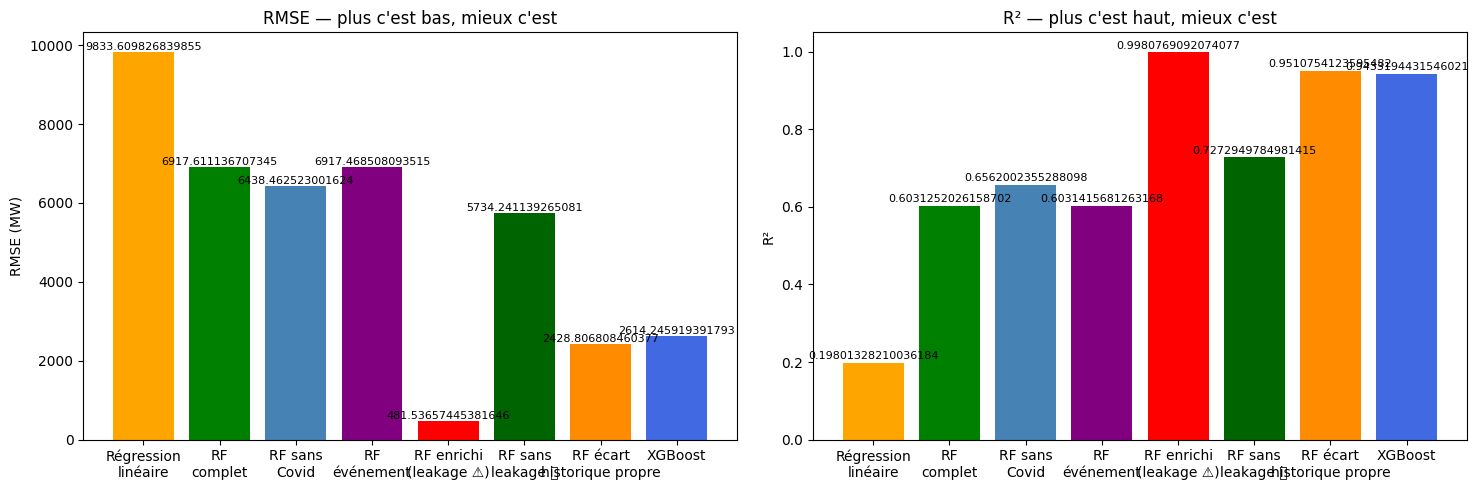

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

modeles = [
    "Régression\nlinéaire",
    "RF\ncomplet",
    "RF sans\nCovid",
    "RF\névénement",
    "RF enrichi\n(leakage ⚠️)",
    "RF sans\nleakage ✅",
    "RF écart\nhistorique propre",
    "XGBoost"
]
rmses  = [rmse_lr, rmse_rf, rmse_A, rmse_B, rmse_C, rmse_D, rmse_E, rmse_F]
r2s    = [r2_lr,   r2_rf,   r2_A,   r2_B,   r2_C,   r2_D,   r2_E,   r2_F]
colors = ["orange", "green", "steelblue", "purple", "red", "darkgreen", "darkorange", "royalblue"]

axes[0].bar(modeles, rmses, color=colors)
axes[0].set_title("RMSE — plus c'est bas, mieux c'est")
axes[0].set_ylabel("RMSE (MW)")
for i, v in enumerate(rmses):
    axes[0].text(i, v + 50, str(v), ha="center", fontsize=8)

axes[1].bar(modeles, r2s, color=colors)
axes[1].set_title("R² — plus c'est haut, mieux c'est")
axes[1].set_ylabel("R²")
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(r2s):
    axes[1].text(i, v + 0.01, str(v), ha="center", fontsize=8)

plt.tight_layout()
plt.show()

C:\Users\Fefe\AppData\Local\Temp\ipykernel_29416\2032332276.py:28: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


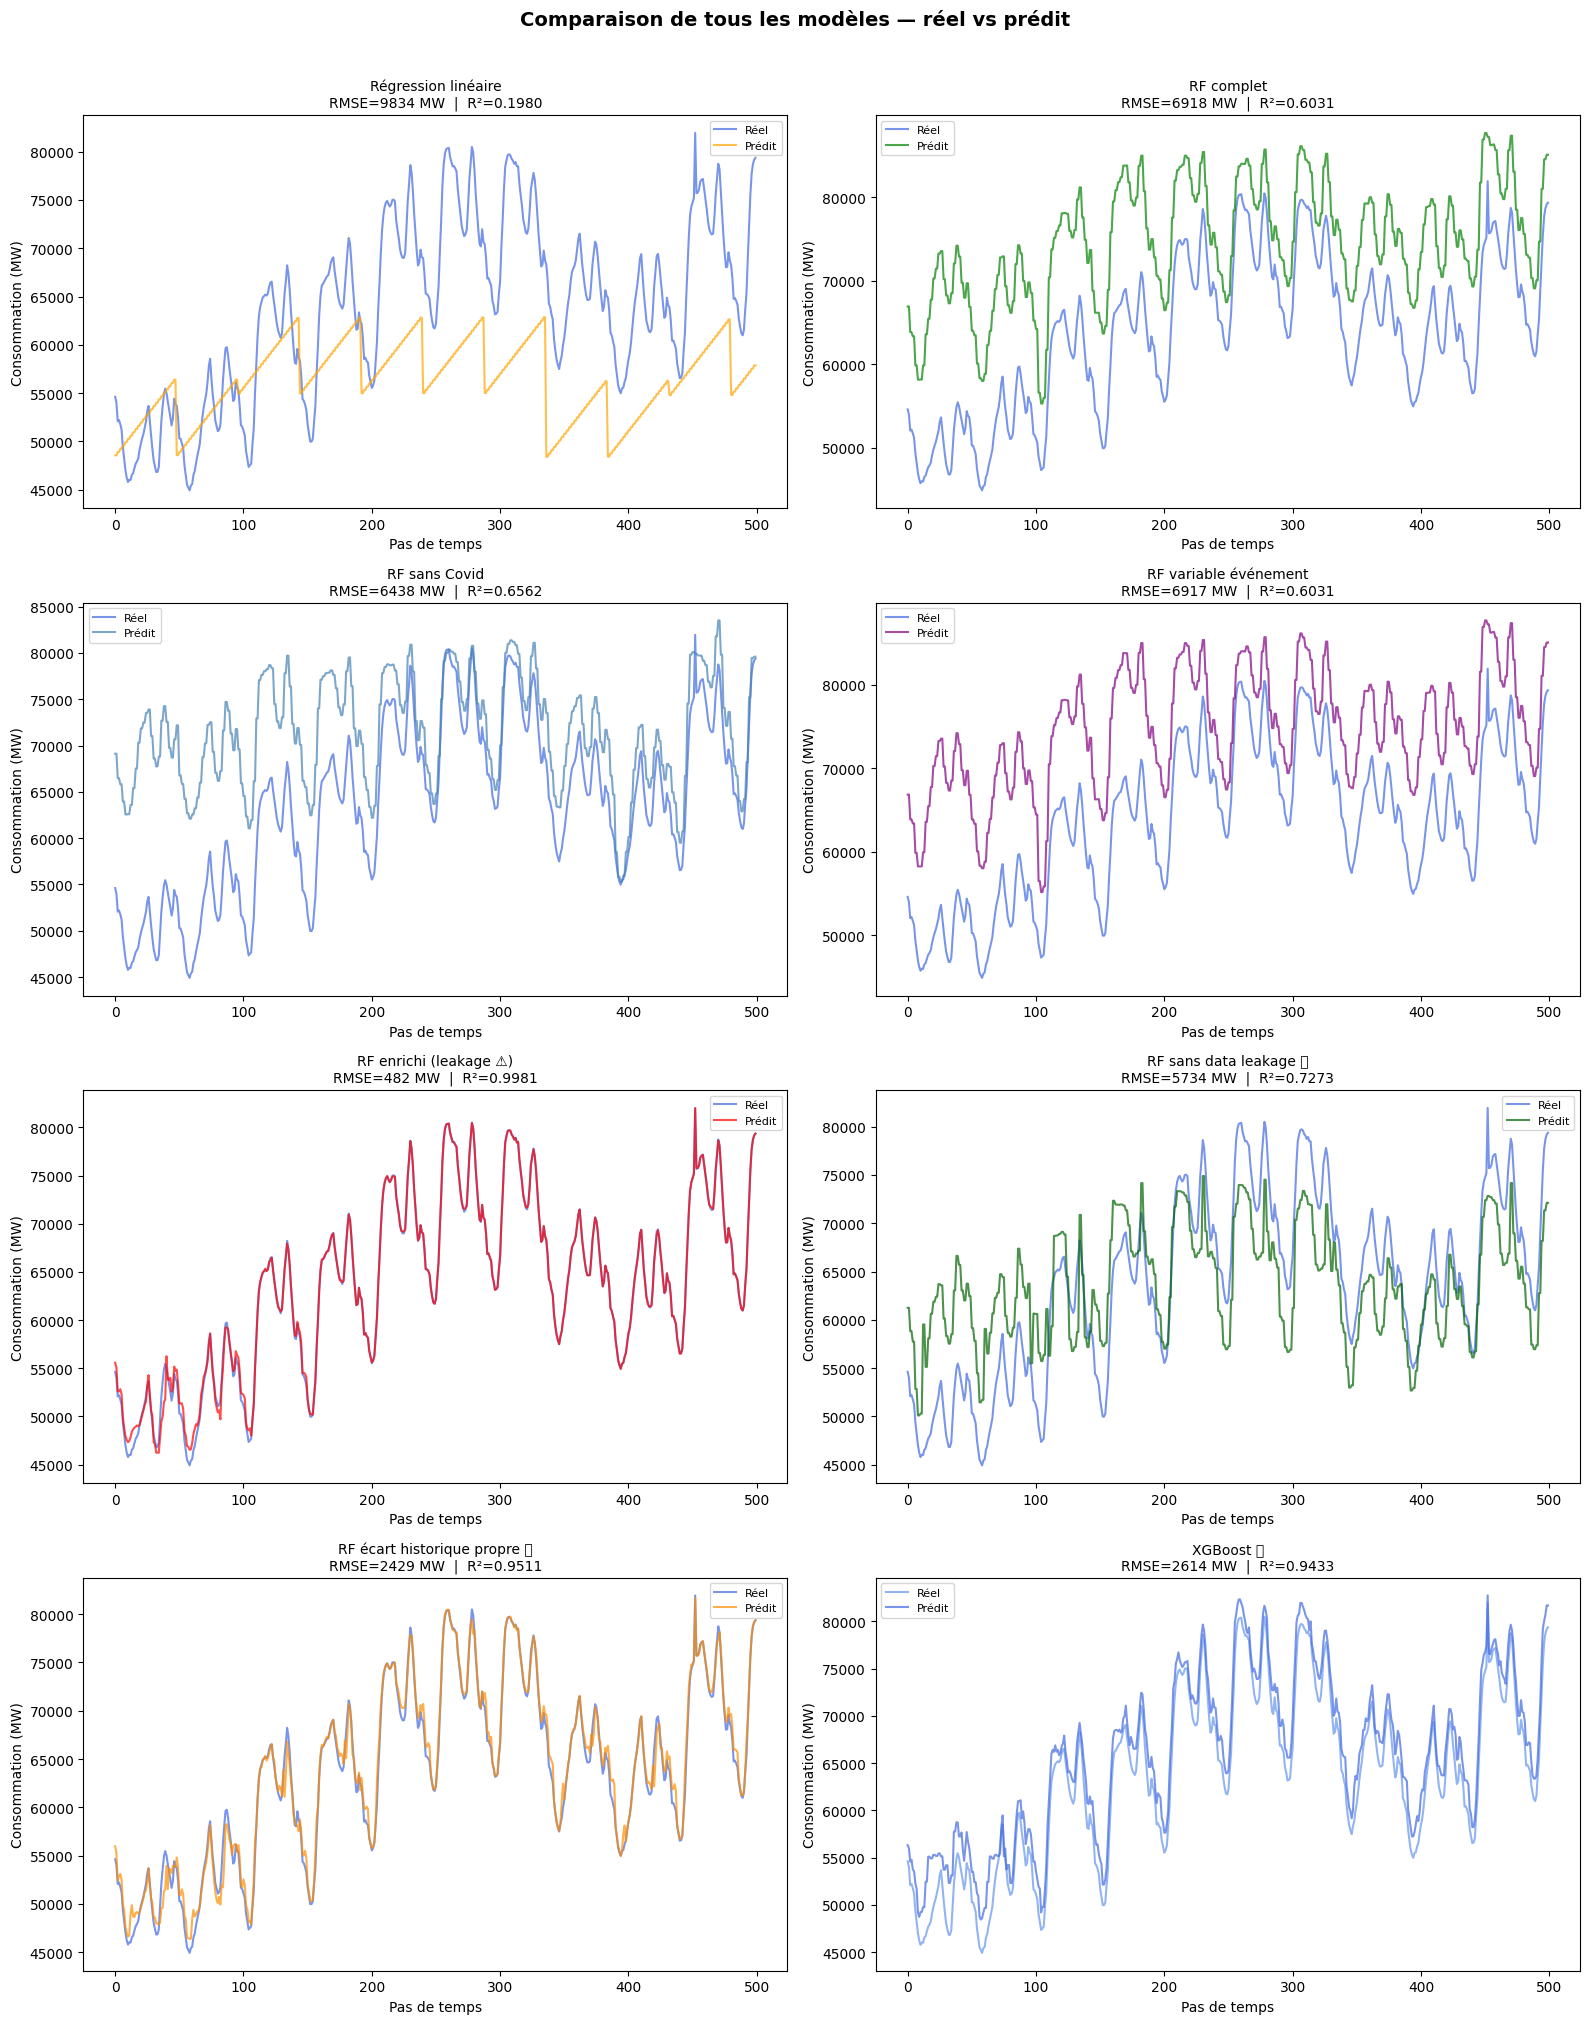

In [109]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

modeles_info = [
    (y_test.values,   y_pred_lr, "Régression linéaire",              "orange",     rmse_lr, r2_lr),
    (y_test.values,   y_pred_rf, "RF complet",                       "green",      rmse_rf, r2_rf),
    (y_test_A.values, y_pred_A,  "RF sans Covid",                    "steelblue",  rmse_A,  r2_A),
    (y_test_B.values, y_pred_B,  "RF variable événement",            "purple",     rmse_B,  r2_B),
    (y_test_C.values, y_pred_C,  "RF enrichi (leakage ⚠️)",          "red",        rmse_C,  r2_C),
    (y_test_D.values, y_pred_D,  "RF sans data leakage ✅",          "darkgreen",  rmse_D,  r2_D),
    (y_test_E.values, y_pred_E,  "RF écart historique propre ✅",    "darkorange", rmse_E,  r2_E),
    (y_test_E.values, y_pred_F,  "XGBoost ✅",                       "royalblue",  rmse_F,  r2_F),
]

sample = 500

for i, (y_reel, y_pred, titre, couleur, rmse_val, r2_val) in enumerate(modeles_info):
    axes[i].plot(y_reel[:sample], label="Réel", alpha=0.7,
                 color="royalblue" if couleur != "royalblue" else "cornflowerblue")
    axes[i].plot(y_pred[:sample], label="Prédit", alpha=0.7, color=couleur)
    axes[i].set_title(f"{titre}\nRMSE={rmse_val:.0f} MW  |  R²={r2_val:.4f}", fontsize=10)
    axes[i].set_xlabel("Pas de temps")
    axes[i].set_ylabel("Consommation (MW)")
    axes[i].legend(fontsize=8)

plt.suptitle("Comparaison de tous les modèles — réel vs prédit",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

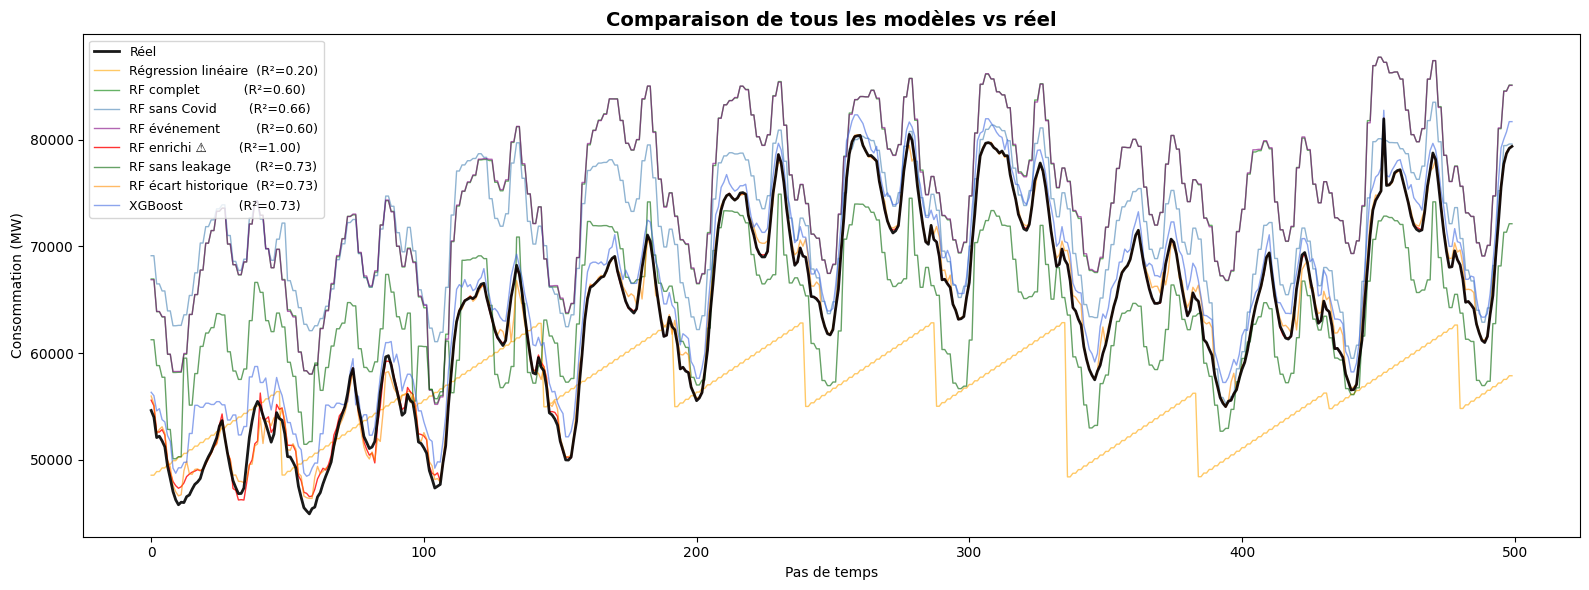

In [110]:
sample = 500

plt.figure(figsize=(16, 6))

# Réel en noir épais pour bien le voir
plt.plot(y_test_D.values[:sample], label="Réel", 
         color="black", linewidth=2, alpha=0.9, zorder=10)

# Tous les modèles
plt.plot(y_pred_lr[:sample],  label=f"Régression linéaire  (R²={r2_lr:.2f})",  color="orange",    alpha=0.6, linewidth=1)
plt.plot(y_pred_rf[:sample],  label=f"RF complet           (R²={r2_rf:.2f})",  color="green",     alpha=0.6, linewidth=1)
plt.plot(y_pred_A[:sample],   label=f"RF sans Covid        (R²={r2_A:.2f})",   color="steelblue", alpha=0.6, linewidth=1)
plt.plot(y_pred_B[:sample],   label=f"RF événement         (R²={r2_B:.2f})",   color="purple",    alpha=0.6, linewidth=1)
plt.plot(y_pred_C[:sample],   label=f"RF enrichi ⚠️        (R²={r2_C:.2f})",   color="red",       alpha=0.8, linewidth=1)
plt.plot(y_pred_D[:sample],   label=f"RF sans leakage      (R²={r2_D:.2f})",   color="darkgreen", alpha=0.6, linewidth=1)
plt.plot(y_pred_E[:sample],   label=f"RF écart historique  (R²={r2_D:.2f})",   color="darkorange", alpha=0.6, linewidth=1)
plt.plot(y_pred_F[:sample],   label=f"XGBoost              (R²={r2_D:.2f})",   color="royalblue", alpha=0.6, linewidth=1)

plt.title("Comparaison de tous les modèles vs réel", fontsize=14, fontweight="bold")
plt.xlabel("Pas de temps")
plt.ylabel("Consommation (MW)")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

In [129]:
# Créer un DataFrame avec les prédictions journalières
# On récupère les dates correspondant au jeu de test E

df_test_E = df_E[test_mask_E].dropna(subset=features_E).copy()
df_test_E = df_test_E.loc[X_test_E.index]

# Ajout de toutes les prédictions
df_test_E["pred_lr"]  = y_pred_lr
df_test_E["pred_rf"]  = y_pred_rf
df_test_E["pred_A"]   = y_pred_A
df_test_E["pred_E"]   = y_pred_E
df_test_E["pred_F"]   = y_pred_F
df_test_E["pred_E2"]  = y_pred_E2
df_test_E["pred_F2"]  = y_pred_F2

# Agrégation par jour (moyenne des 48 pas de 30min)
df_daily = df_test_E.groupby("Date").agg(
    Consommation  = ("Consommation", "mean"),
    pred_lr       = ("pred_lr",      "mean"),
    pred_rf       = ("pred_rf",      "mean"),
    pred_A        = ("pred_A",       "mean"),
    pred_E        = ("pred_E",       "mean"),
    pred_F        = ("pred_F",       "mean"),
    pred_E2       = ("pred_E2",      "mean"),
    pred_F2       = ("pred_F2",      "mean"),
    year          = ("year",         "first")
).reset_index()

df_daily["Date"] = pd.to_datetime(df_daily["Date"])
df_daily = df_daily.sort_values("Date").reset_index(drop=True)

print(f"Nombre de jours : {len(df_daily)}")
print(f"Période : {df_daily['Date'].min().date()} → {df_daily['Date'].max().date()}")

Nombre de jours : 821
Période : 2022-01-01 → 2024-03-31


C:\Users\Fefe\AppData\Local\Temp\ipykernel_29416\438795791.py:42: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Fefe\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


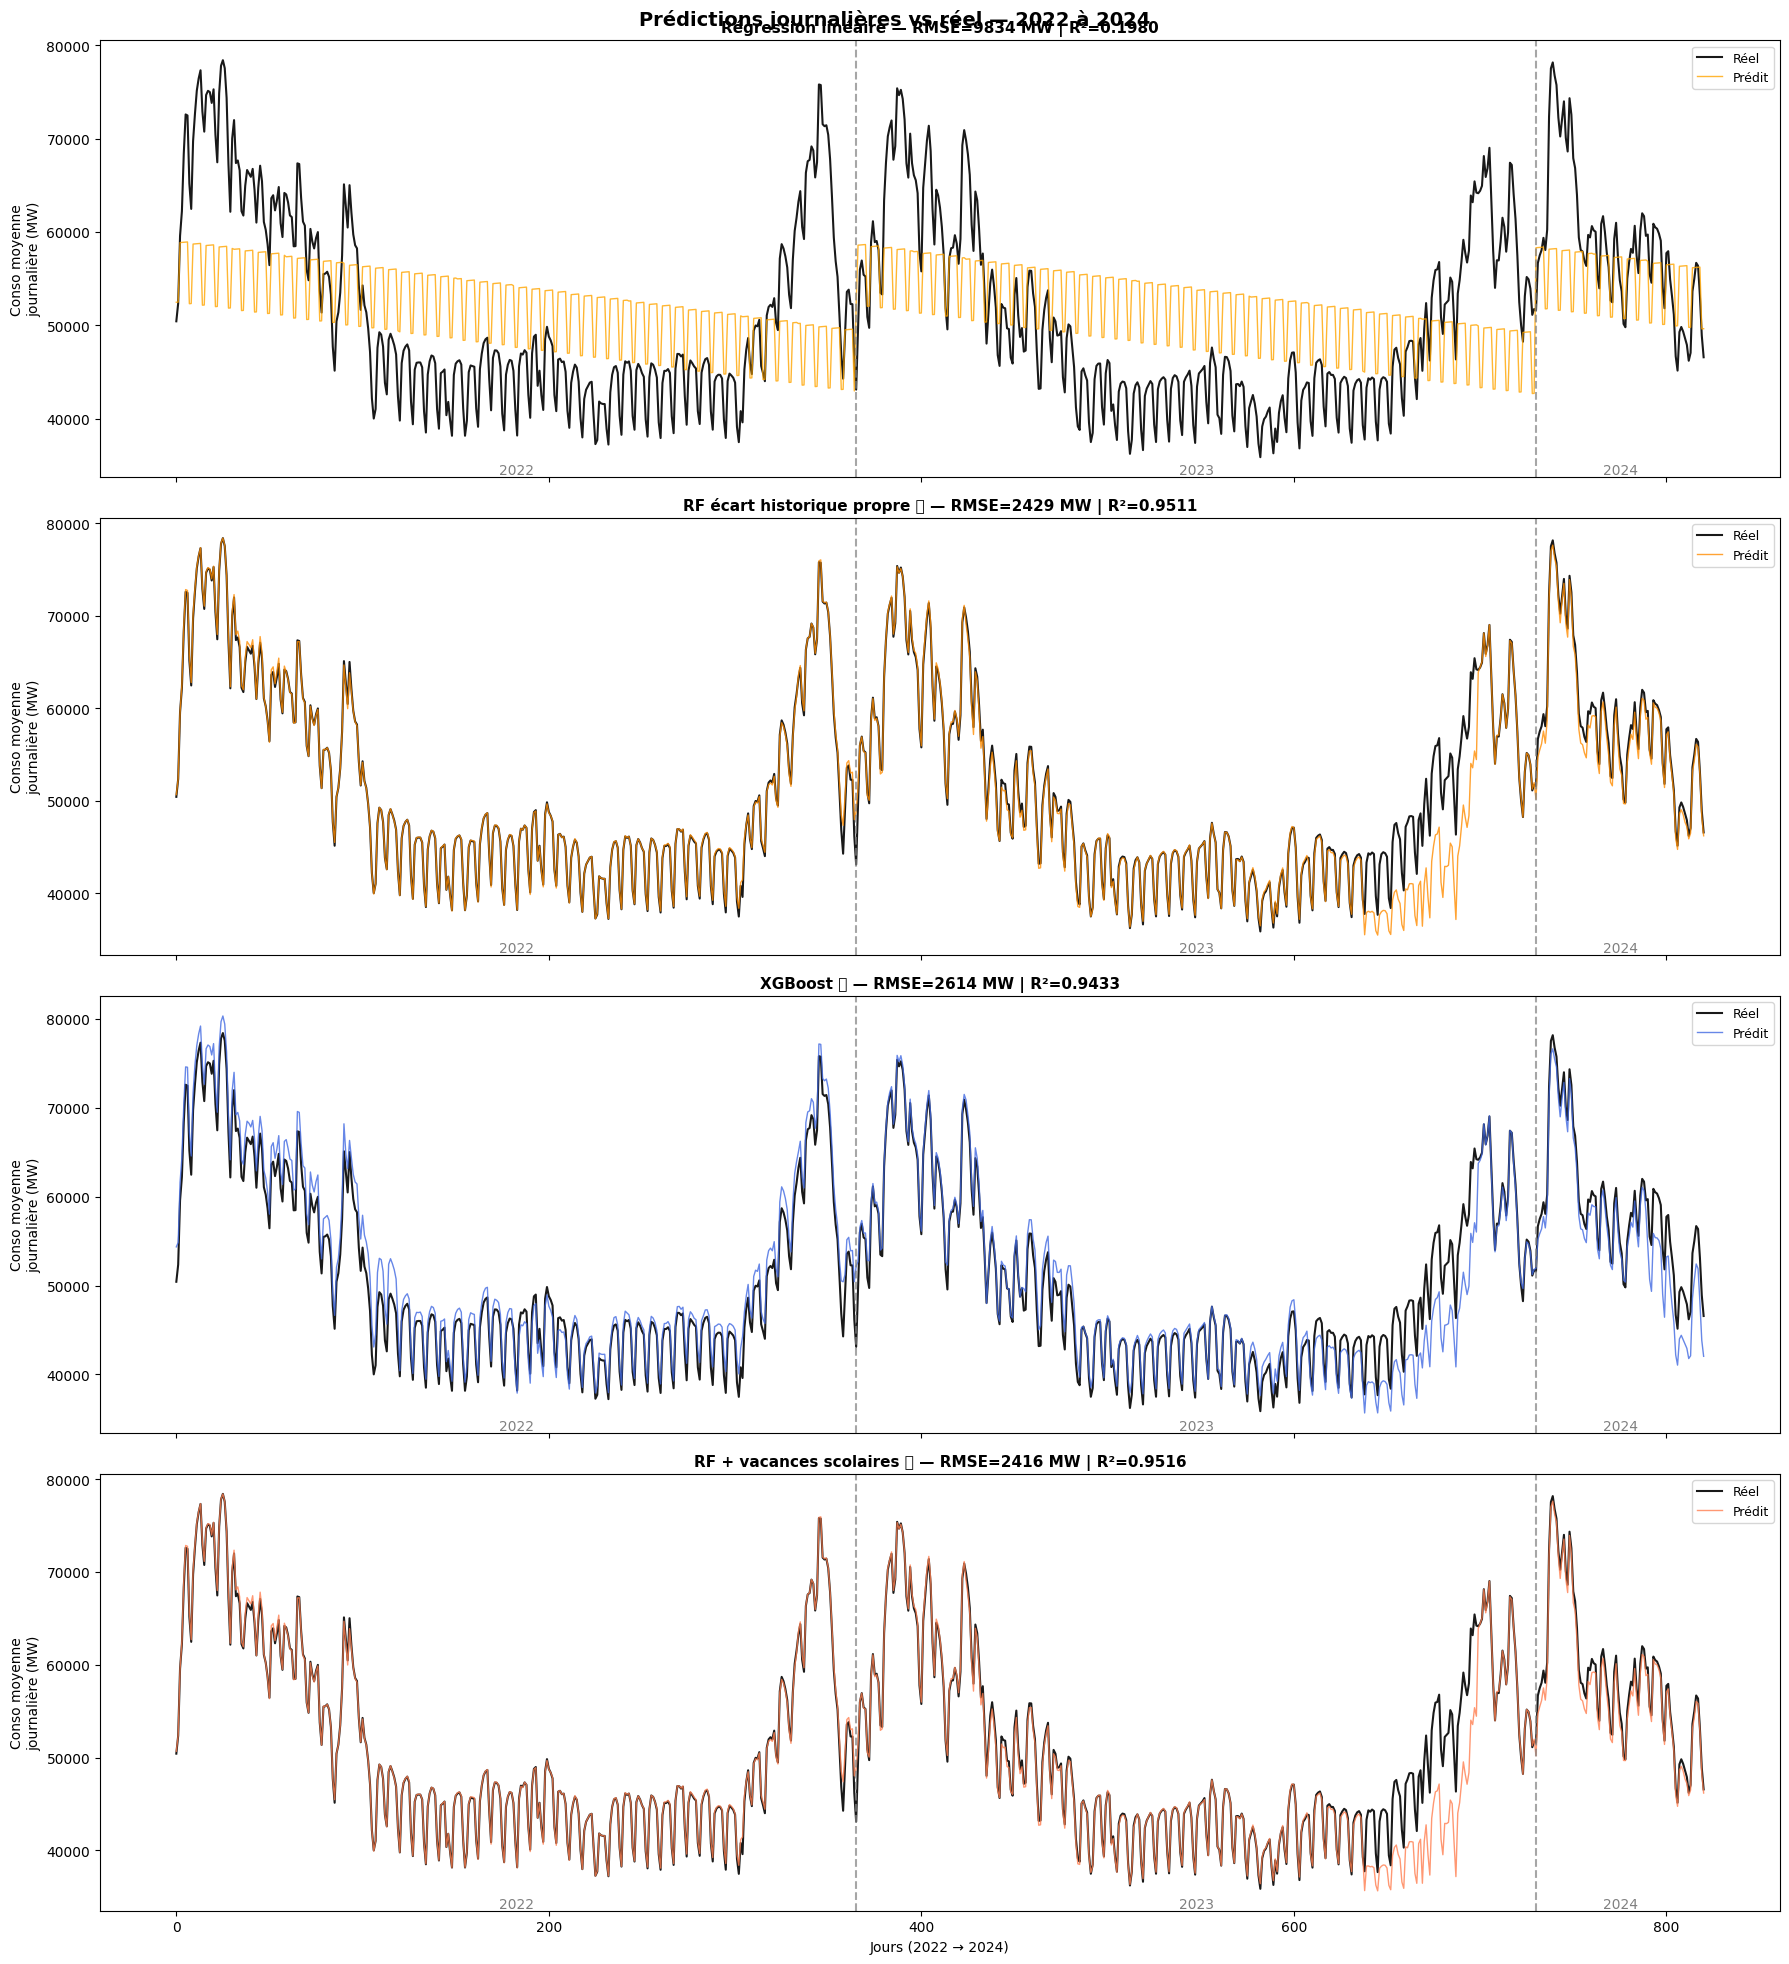

In [130]:
# Délimitations des années
limite_2023 = df_daily[df_daily["year"] == 2023].index[0]
limite_2024 = df_daily[df_daily["year"] == 2024].index[0]

fig, axes = plt.subplots(4, 1, figsize=(18, 20), sharex=True)

modeles_daily = [
    ("pred_lr",  "Régression linéaire",           "orange",     rmse_lr, r2_lr),
    ("pred_E",   "RF écart historique propre ✅",  "darkorange", rmse_E,  r2_E),
    ("pred_F",   "XGBoost ✅",                     "royalblue",  rmse_F,  r2_F),
    ("pred_E2",  "RF + vacances scolaires ✅",     "coral",      rmse_E2, r2_E2),
]

for ax, (col, titre, couleur, rmse_val, r2_val) in zip(axes, modeles_daily):
    ax.plot(df_daily.index, df_daily["Consommation"],
            label="Réel", color="black", linewidth=1.5, alpha=0.9)
    ax.plot(df_daily.index, df_daily[col],
            label="Prédit", color=couleur, linewidth=1, alpha=0.8)

    # Traits verticaux entre les années
    ax.axvline(x=limite_2023, color="gray", linestyle="--",
               linewidth=1.5, alpha=0.7)
    ax.axvline(x=limite_2024, color="gray", linestyle="--",
               linewidth=1.5, alpha=0.7)

    # Labels des années
    ax.text(limite_2023 / 2, ax.get_ylim()[0] * 1.01,
            "2022", fontsize=10, color="gray", ha="center")
    ax.text((limite_2023 + limite_2024) / 2, ax.get_ylim()[0] * 1.01,
            "2023", fontsize=10, color="gray", ha="center")
    ax.text((limite_2024 + len(df_daily)) / 2, ax.get_ylim()[0] * 1.01,
            "2024", fontsize=10, color="gray", ha="center")

    ax.set_title(f"{titre} — RMSE={rmse_val:.0f} MW | R²={r2_val:.4f}",
                 fontsize=11, fontweight="bold")
    ax.set_ylabel("Conso moyenne\njournalière (MW)")
    ax.legend(loc="upper right", fontsize=9)

axes[-1].set_xlabel("Jours (2022 → 2024)")
plt.suptitle("Prédictions journalières vs réel — 2022 à 2024",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\Fefe\AppData\Local\Temp\ipykernel_29416\1977254239.py:214: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("poster_consommation.png", dpi=150,
c:\Users\Fefe\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


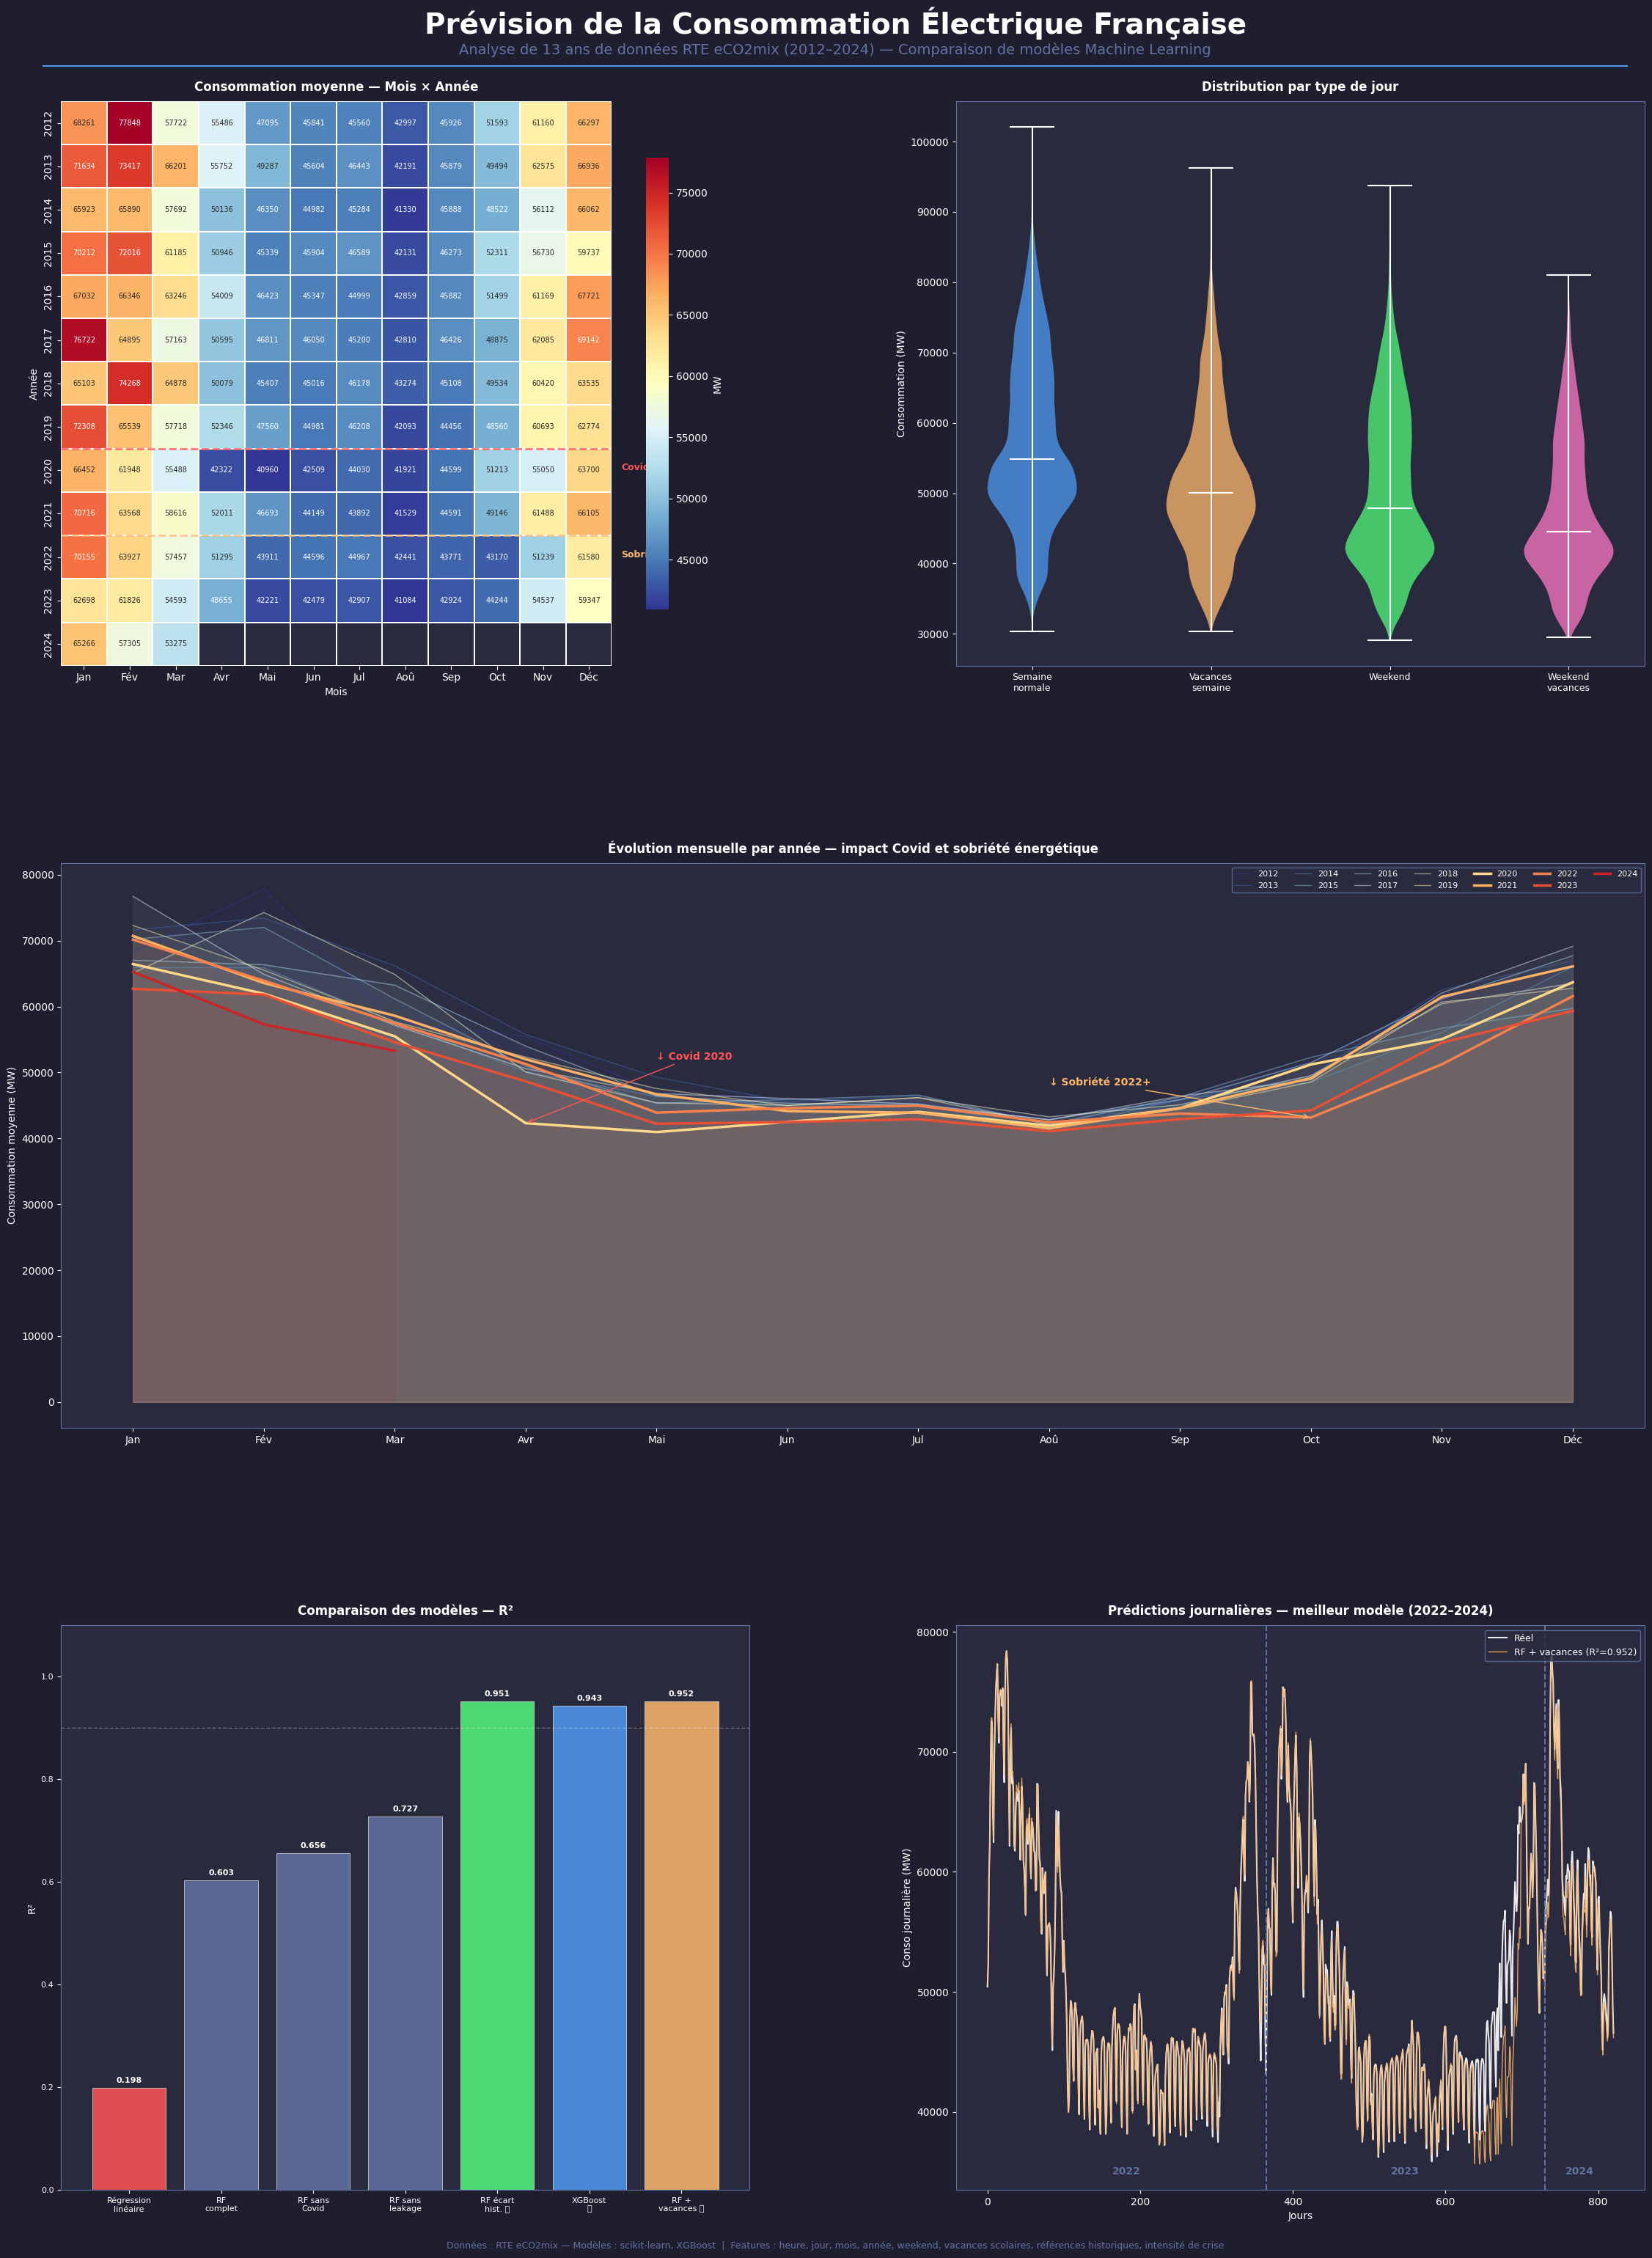

Poster sauvegardé : poster_consommation.png ✅


In [131]:
# ============================================================
# POSTER — Prévision de la consommation électrique française
# ============================================================

plt.style.use("dark_background")

fig = plt.figure(figsize=(24, 32))
fig.patch.set_facecolor("#1e1e2e")

# Couleurs du thème
bg_color     = "#1e1e2e"
panel_color  = "#2a2a3e"
text_color   = "#ffffff"
accent_color = "#4e9af1"
green_color  = "#50fa7b"
orange_color = "#ffb86c"
red_color    = "#ff5555"
gray_color   = "#6272a4"

# ---- TITRE ----
fig.text(0.5, 0.97, "Prévision de la Consommation Électrique Française",
         ha="center", va="top", fontsize=28, fontweight="bold",
         color=text_color)
fig.text(0.5, 0.955, "Analyse de 13 ans de données RTE eCO2mix (2012–2024) — Comparaison de modèles Machine Learning",
         ha="center", va="top", fontsize=14, color=gray_color)

# Ligne de séparation titre
fig.add_artist(plt.Line2D([0.05, 0.95], [0.945, 0.945],
               color=accent_color, linewidth=1.5, transform=fig.transFigure))

# ============================================================
# LAYOUT : grille de subplots
# ============================================================
# Ligne 1 : Heatmap Mois x Année (grande) | Violin plot
# Ligne 2 : Courbes annuelles superposées (grande)
# Ligne 3 : Barplot R² comparaison | Prédictions journalières
# ============================================================

gs = fig.add_gridspec(3, 2,
                      left=0.06, right=0.96,
                      top=0.93, bottom=0.04,
                      hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])   # Heatmap Mois x Année
ax2 = fig.add_subplot(gs[0, 1])   # Violin plot
ax3 = fig.add_subplot(gs[1, :])   # Courbes annuelles (pleine largeur)
ax4 = fig.add_subplot(gs[2, 0])   # Barplot R²
ax5 = fig.add_subplot(gs[2, 1])   # Prédictions journalières (meilleur modèle)

for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.set_facecolor(panel_color)
    for spine in ax.spines.values():
        spine.set_edgecolor(gray_color)

# ============================================================
# GRAPHIQUE 1 — Heatmap Mois x Année
# ============================================================
hm2 = df_E.groupby(["year", "month"])["Consommation"].mean().unstack()
hm2.columns = ["Jan","Fév","Mar","Avr","Mai","Jun",
               "Jul","Aoû","Sep","Oct","Nov","Déc"]

sns.heatmap(hm2, ax=ax1, cmap="RdYlBu_r", annot=True, fmt=".0f",
            linewidths=0.3, annot_kws={"size": 7},
            cbar_kws={"label": "MW", "shrink": 0.8})

ax1.set_title("Consommation moyenne — Mois × Année",
              fontsize=12, fontweight="bold", color=text_color, pad=10)
ax1.set_xlabel("Mois", color=text_color)
ax1.set_ylabel("Année", color=text_color)
ax1.tick_params(colors=text_color)

# Annotations Covid et sobriété
ax1.axhline(y=8, color=red_color,    linewidth=2, linestyle="--", alpha=0.8)
ax1.axhline(y=10, color=orange_color, linewidth=2, linestyle="--", alpha=0.8)
ax1.text(12.2, 8.5,  "Covid",    color=red_color,    fontsize=9, fontweight="bold")
ax1.text(12.2, 10.5, "Sobriété", color=orange_color, fontsize=9, fontweight="bold")

# ============================================================
# GRAPHIQUE 2 — Violin plot
# ============================================================
data_violin = [
    df_E[df_E["type_jour"] == t]["Consommation"].values
    for t in ["Semaine normale", "Vacances (semaine)", "Weekend", "Weekend vacances"]
]

parts = ax2.violinplot(data_violin, positions=[1, 2, 3, 4],
                       showmedians=True, showextrema=True)

colors_v = [accent_color, orange_color, green_color, "#ff79c6"]
for pc, color in zip(parts["bodies"], colors_v):
    pc.set_facecolor(color)
    pc.set_alpha(0.75)
parts["cmedians"].set_color("white")
parts["cmaxes"].set_color("white")
parts["cmins"].set_color("white")
parts["cbars"].set_color("white")

ax2.set_xticks([1, 2, 3, 4])
ax2.set_xticklabels(["Semaine\nnormale", "Vacances\nsemaine",
                     "Weekend", "Weekend\nvacances"],
                    color=text_color, fontsize=9)
ax2.set_title("Distribution par type de jour",
              fontsize=12, fontweight="bold", color=text_color, pad=10)
ax2.set_ylabel("Consommation (MW)", color=text_color)
ax2.tick_params(colors=text_color)

# ============================================================
# GRAPHIQUE 3 — Courbes annuelles superposées
# ============================================================
conso_mois_annee = df_E.groupby(["year", "month"])["Consommation"].mean().unstack(0)

cmap_years = plt.cm.RdYlBu_r
n_years = len(conso_mois_annee.columns)

for i, year in enumerate(conso_mois_annee.columns):
    color = cmap_years(i / n_years)
    lw    = 2.5 if year in [2020, 2021, 2022, 2023, 2024] else 1
    alpha = 1.0 if year in [2020, 2021, 2022, 2023, 2024] else 0.5
    ax3.plot(range(1, 13), conso_mois_annee[year],
             color=color, linewidth=lw, alpha=alpha, label=str(year))
    ax3.fill_between(range(1, 13), conso_mois_annee[year],
                     alpha=0.05, color=color)

ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(["Jan","Fév","Mar","Avr","Mai","Jun",
                     "Jul","Aoû","Sep","Oct","Nov","Déc"],
                    color=text_color)
ax3.set_title("Évolution mensuelle par année — impact Covid et sobriété énergétique",
              fontsize=12, fontweight="bold", color=text_color, pad=10)
ax3.set_ylabel("Consommation moyenne (MW)", color=text_color)
ax3.tick_params(colors=text_color)
ax3.legend(loc="upper right", fontsize=8, ncol=7,
           facecolor=panel_color, edgecolor=gray_color,
           labelcolor=text_color)

# Annotations
ax3.annotate("↓ Covid 2020", xy=(4, conso_mois_annee[2020][4]),
             xytext=(5, 52000), color=red_color, fontsize=10,
             fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=red_color))
ax3.annotate("↓ Sobriété 2022+", xy=(10, conso_mois_annee[2022][10]),
             xytext=(8, 48000), color=orange_color, fontsize=10,
             fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=orange_color))

# ============================================================
# GRAPHIQUE 4 — Barplot comparaison R²
# ============================================================
modeles_noms = [
    "Régression\nlinéaire",
    "RF\ncomplet",
    "RF sans\nCovid",
    "RF sans\nleakage",
    "RF écart\nhist. ✅",
    "XGBoost\n✅",
    "RF +\nvacances ✅"
]
r2_vals   = [r2_lr, r2_rf, r2_A, r2_D, r2_E, r2_F, r2_E2]
rmse_vals = [rmse_lr, rmse_rf, rmse_A, rmse_D, rmse_E, rmse_F, rmse_E2]
bar_colors = [red_color, gray_color, gray_color, gray_color,
              green_color, accent_color, orange_color]

bars = ax4.bar(modeles_noms, r2_vals, color=bar_colors, alpha=0.85, edgecolor="white", linewidth=0.5)
ax4.set_ylim(0, 1.1)
ax4.set_title("Comparaison des modèles — R²",
              fontsize=12, fontweight="bold", color=text_color, pad=10)
ax4.set_ylabel("R²", color=text_color)
ax4.tick_params(colors=text_color, labelsize=8)
ax4.axhline(y=0.9, color="white", linestyle="--", alpha=0.3, linewidth=1)

for bar, val in zip(bars, r2_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f"{val:.3f}", ha="center", fontsize=8,
             color=text_color, fontweight="bold")

# ============================================================
# GRAPHIQUE 5 — Prédictions journalières meilleur modèle
# ============================================================
ax5.plot(df_daily.index, df_daily["Consommation"],
         label="Réel", color="white", linewidth=1.5, alpha=0.9)
ax5.plot(df_daily.index, df_daily["pred_E2"],
         label=f"RF + vacances (R²={r2_E2:.3f})",
         color=orange_color, linewidth=1, alpha=0.85)

ax5.axvline(x=limite_2023, color=gray_color, linestyle="--", linewidth=1.5)
ax5.axvline(x=limite_2024, color=gray_color, linestyle="--", linewidth=1.5)

ymin = df_daily["Consommation"].min() * 0.97
ax5.text(limite_2023 / 2,              ymin, "2022", ha="center",
         fontsize=10, color=gray_color, fontweight="bold")
ax5.text((limite_2023 + limite_2024)/2, ymin, "2023", ha="center",
         fontsize=10, color=gray_color, fontweight="bold")
ax5.text((limite_2024 + len(df_daily))/2, ymin, "2024", ha="center",
         fontsize=10, color=gray_color, fontweight="bold")

ax5.set_title("Prédictions journalières — meilleur modèle (2022–2024)",
              fontsize=12, fontweight="bold", color=text_color, pad=10)
ax5.set_ylabel("Conso journalière (MW)", color=text_color)
ax5.set_xlabel("Jours", color=text_color)
ax5.tick_params(colors=text_color)
ax5.legend(loc="upper right", fontsize=9,
           facecolor=panel_color, edgecolor=gray_color,
           labelcolor=text_color)

# ============================================================
# FOOTER
# ============================================================
fig.text(0.5, 0.015,
         "Données : RTE eCO2mix — Modèles : scikit-learn, XGBoost  |  "
         "Features : heure, jour, mois, année, weekend, vacances scolaires, "
         "références historiques, intensité de crise",
         ha="center", fontsize=9, color=gray_color)

plt.savefig("poster_consommation.png", dpi=150,
            bbox_inches="tight", facecolor=bg_color)
plt.show()
print("Poster sauvegardé : poster_consommation.png ✅")